# Financial Stress Indicator Forecasting

## Forecasting U.S. Financial Stress Changes Using Market-Based Indicators

This notebook prepares the raw financial-market data for Analysis B of the Time Series final project. The objective is to study whether market-based financial indicators help forecast next-week changes in U.S. financial stress, using the St. Louis Fed Financial Stress Index (`STLFSI4`) as the official stress target.

The analysis uses weekly financial stress data and market indicators representing several stress channels:

1. **Equity volatility:** VIX
2. **Credit-market stress:** Baa corporate credit spread
3. **Interest-rate expectations:** 2-year and 10-year Treasury yields
4. **Yield-curve pressure:** 10Y–2Y Treasury spread
5. **Equity-market performance:** S&P 500 returns

## Research Questions

1. **Which financial channel provides the strongest incremental signal for next-week changes in U.S. financial stress: equity volatility, credit spreads, equity returns, or interest-rate/yield-curve variables?**

2. **Do volatility, credit, equity, and yield-curve indicators move together with financial stress, or does one channel consistently lead changes in `STLFSI4` by one to four weeks?**

3. **Do nonlinear models reduce forecast error during high-stress-acceleration weeks compared with ARIMA, ARIMAX, and VAR?**


In [1]:
# Financial Stress Indicator Forecasting
# Load clean modeling dataset

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

CLEAN_DATA_PATH = Path(
    r"C:\Users\DiBip\Downloads\Georgia Tech\Time Series Analysis\Final Project\Financial Stress Indicators"
)

clean_file = CLEAN_DATA_PATH / "fsi_model_data.csv"

df = pd.read_csv(clean_file)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum())

display(df.head())
display(df.tail())

Dataset loaded successfully.
Shape: (516, 26)
Date range: 2016-06-03 00:00:00 to 2026-04-17 00:00:00

Columns:
['date', 'stress', 'vix', 'dgs2', 'dgs10', 'yield_curve', 'credit_spread', 'sp500_return', 'stress_next', 'stress_change_next', 'stress_lag1', 'stress_lag4', 'vix_lag1', 'vix_lag4', 'dgs2_lag1', 'dgs2_lag4', 'dgs10_lag1', 'dgs10_lag4', 'yield_curve_lag1', 'yield_curve_lag4', 'credit_spread_lag1', 'credit_spread_lag4', 'sp500_return_lag1', 'sp500_return_lag4', 'sp500_return_4w_mean', 'sp500_abs_return_4w_mean']

Missing values:


date                        0
stress                      0
vix                         0
dgs2                        0
dgs10                       0
yield_curve                 0
credit_spread               0
sp500_return                0
stress_next                 0
stress_change_next          0
stress_lag1                 0
stress_lag4                 0
vix_lag1                    0
vix_lag4                    0
dgs2_lag1                   0
dgs2_lag4                   0
dgs10_lag1                  0
dgs10_lag4                  0
yield_curve_lag1            0
yield_curve_lag4            0
credit_spread_lag1          0
credit_spread_lag4          0
sp500_return_lag1           0
sp500_return_lag4           0
sp500_return_4w_mean        0
sp500_abs_return_4w_mean    0
dtype: int64

,date,stress,vix,dgs2,dgs10,yield_curve,credit_spread,sp500_return,stress_next,stress_change_next,...,dgs10_lag1,dgs10_lag4,yield_curve_lag1,yield_curve_lag4,credit_spread_lag1,credit_spread_lag4,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean
0,2016-06-03,0.1254,13.47,0.78,1.71,0.93,2.86,0.001034,0.1522,0.0268,...,1.85,1.79,0.95,1.05,2.85,2.87,0.022519,-0.011738,0.002109,0.010544
1,2016-06-10,0.1522,17.03,0.73,1.64,0.91,2.86,-0.001459,0.5669,0.4147,...,1.71,1.71,0.93,0.95,2.86,2.90,0.001034,-0.005132,0.005302,0.007868
2,2016-06-17,0.5669,19.41,0.70,1.62,0.92,2.89,-0.011926,0.2572,-0.3097,...,1.64,1.85,0.91,0.96,2.86,2.86,-0.001459,0.002786,0.006220,0.006949
3,2016-06-24,0.2572,25.76,0.64,1.57,0.93,2.98,-0.016458,0.5807,0.3235,...,1.62,1.85,0.92,0.95,2.89,2.85,-0.011926,0.022519,0.002542,0.009235
4,2016-07-01,0.5807,14.77,0.59,1.46,0.87,2.86,0.031662,0.2051,-0.3756,...,1.57,1.71,0.93,0.93,2.98,2.86,-0.016458,0.001034,-0.007202,0.007719


,date,stress,vix,dgs2,dgs10,yield_curve,credit_spread,sp500_return,stress_next,stress_change_next,...,dgs10_lag1,dgs10_lag4,yield_curve_lag1,yield_curve_lag4,credit_spread_lag1,credit_spread_lag4,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean
511,2026-03-20,-0.3658,26.78,3.88,4.39,0.51,1.79,-0.019136,-0.1804,0.1854,...,4.28,4.08,0.55,0.60,1.83,1.69,-0.016128,0.009640,-0.007831,0.012651
512,2026-03-27,-0.1804,31.05,3.88,4.44,0.56,1.78,-0.021380,-0.2404,-0.0600,...,4.39,3.97,0.51,0.59,1.79,1.80,-0.019136,-0.004443,-0.015025,0.015025
513,2026-04-03,-0.2404,23.87,3.84,4.35,0.51,1.74,0.033025,-0.6472,-0.4068,...,4.44,4.15,0.56,0.59,1.78,1.75,-0.021380,-0.020393,-0.019259,0.019259
514,2026-04-10,-0.6472,19.23,3.81,4.31,0.50,1.72,0.030543,-0.7580,-0.1108,...,4.35,4.28,0.51,0.55,1.74,1.83,0.033025,-0.016128,-0.005905,0.022417
515,2026-04-17,-0.7580,17.48,3.71,4.26,0.55,1.72,0.044355,-0.6782,0.0798,...,4.31,4.39,0.50,0.51,1.72,1.79,0.030543,-0.019136,0.005763,0.026021


This notebook starts from the cleaned and merged financial stress modeling dataset created in the separate data cleaning notebook. The dataset contains weekly observations of the St. Louis Fed Financial Stress Index, market-based stress indicators, one-week-ahead stress targets, and lagged predictors.

The primary target for the analysis is `stress_change_next`, which measures the next-week change in the official financial stress index. The secondary target is `stress_next`, which measures the next-week level of financial stress.

# Exploratory Data Analysis

The exploratory data analysis begins by visualizing the official financial stress target and each major market-based predictor. The goal is to understand how the financial stress index and its related market channels behaved over the 2016–2026 sample before fitting forecasting models.

The plots include:

1. St. Louis Fed Financial Stress Index (`stress`)
2. One-week-ahead change in financial stress (`stress_change_next`)
3. VIX (`vix`)
4. Baa corporate credit spread (`credit_spread`)
5. 2-year Treasury yield (`dgs2`)
6. 10-year Treasury yield (`dgs10`)
7. 10Y–2Y yield spread (`yield_curve`)
8. S&P 500 weekly returns (`sp500_return`)

These plots help identify stress spikes, volatility regimes, credit-spread widening, interest-rate shifts, yield-curve pressure, and equity-market drawdowns before formal model fitting.

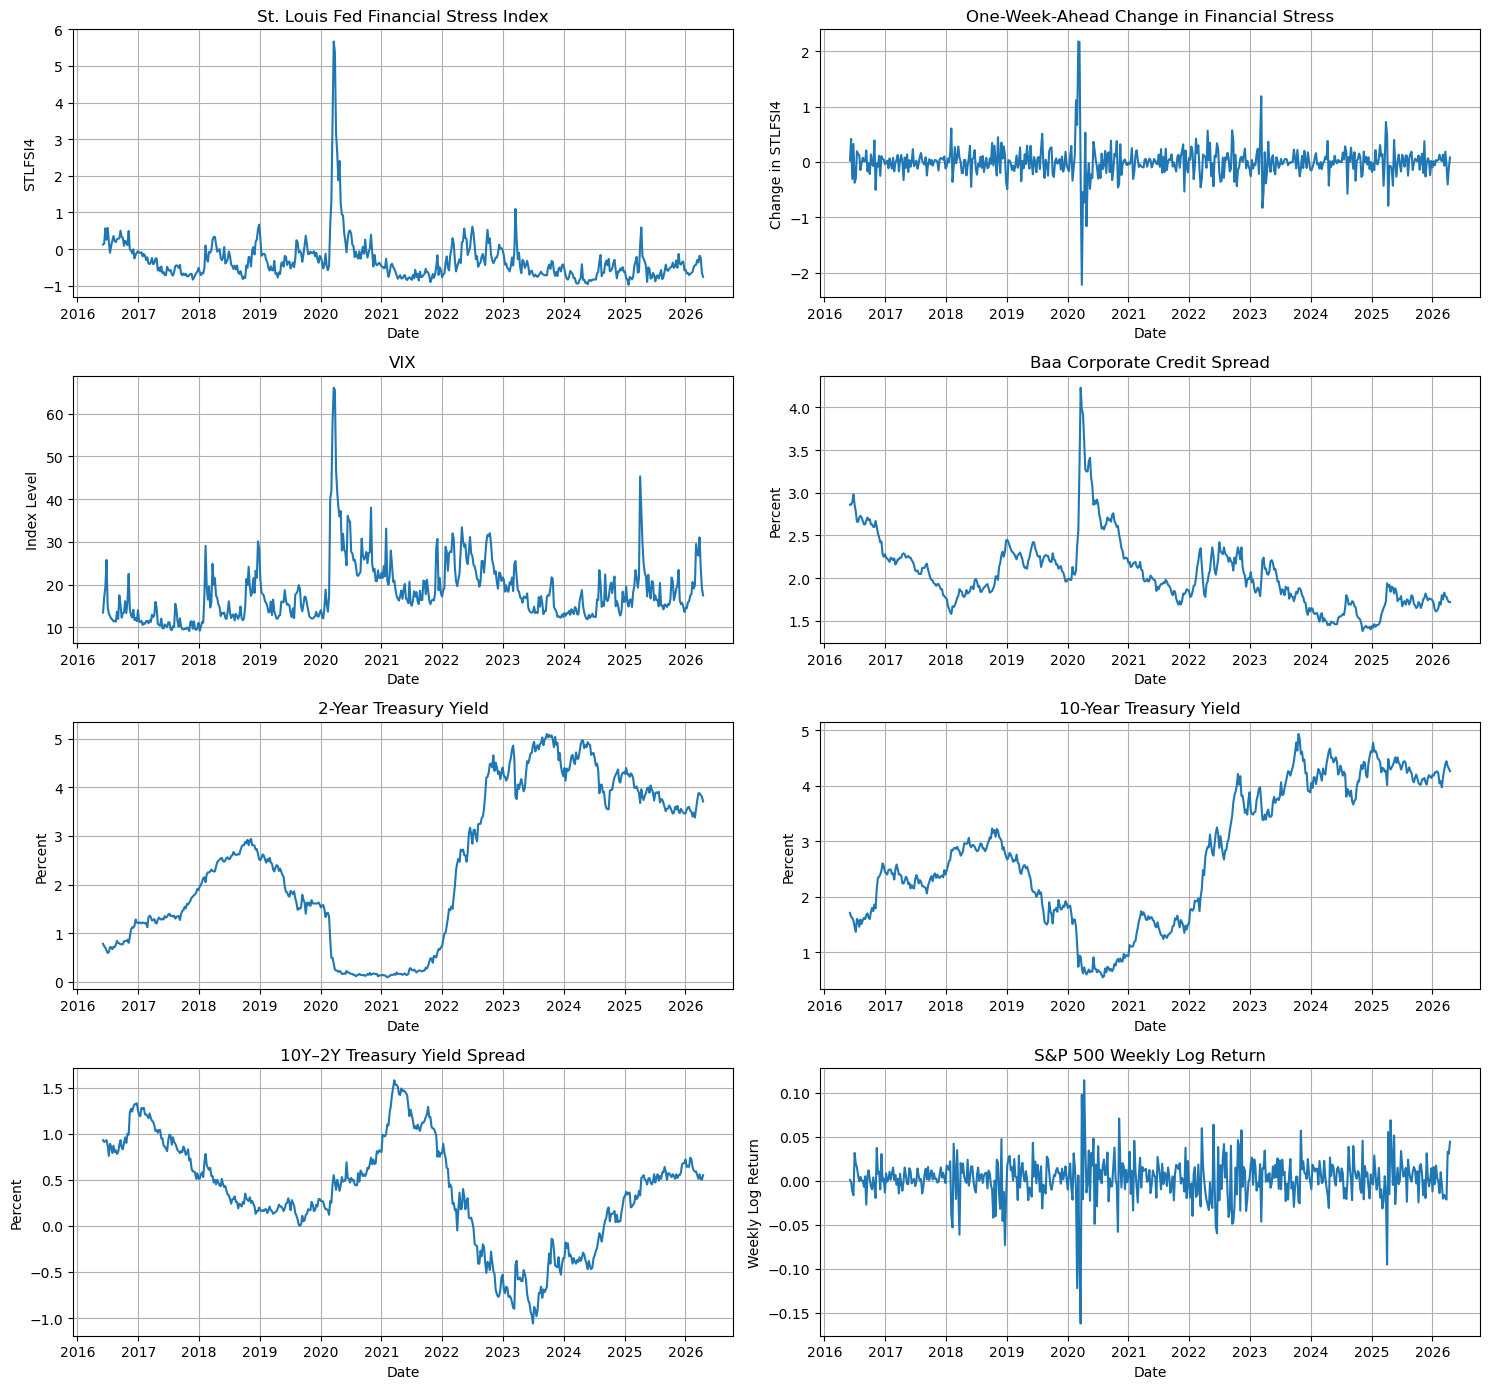

In [2]:
# Plot financial stress target and predictor series

plot_vars = [
    ("stress", "St. Louis Fed Financial Stress Index", "STLFSI4"),
    ("stress_change_next", "One-Week-Ahead Change in Financial Stress", "Change in STLFSI4"),
    ("vix", "VIX", "Index Level"),
    ("credit_spread", "Baa Corporate Credit Spread", "Percent"),
    ("dgs2", "2-Year Treasury Yield", "Percent"),
    ("dgs10", "10-Year Treasury Yield", "Percent"),
    ("yield_curve", "10Y–2Y Treasury Yield Spread", "Percent"),
    ("sp500_return", "S&P 500 Weekly Log Return", "Weekly Log Return")
]

fig, axes = plt.subplots(4, 2, figsize=(15, 14))
axes = axes.flatten()

for ax, (col, title, ylabel) in zip(axes, plot_vars):
    ax.plot(df["date"], df[col])
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    ax.grid(True)

plt.tight_layout()
plt.show()

## Initial EDA Interpretation

The St. Louis Fed Financial Stress Index remains below zero for much of the sample, indicating that financial stress was often below its long-run average. The largest stress spike occurs during the 2020 COVID-19 market shock, when the index rises sharply above 5 before mean-reverting. Smaller stress episodes appear around 2022–2023 and 2025, but none approach the 2020 extreme.

The one-week-ahead stress-change series is centered near zero but contains large positive and negative spikes. This confirms that the stress-change target is more difficult than forecasting the stress level because it focuses on acceleration and reversal rather than persistence.

The VIX and Baa credit spread both spike around the 2020 stress period, but they appear to behave differently. VIX reacts sharply and quickly, while the credit spread rises more gradually and remains elevated for longer. This supports the project’s channel-ranking question: volatility may capture fast uncertainty shocks, while credit spreads may capture more persistent credit-risk stress.

The Treasury variables show a different pattern. The 2-year and 10-year Treasury yields fall sharply around 2020 and rise substantially after 2021 as interest rates increase. The 10Y–2Y spread turns negative during the 2022–2024 period, capturing yield-curve inversion pressure. These variables may provide macro-financial context, but their short-horizon forecasting usefulness needs to be tested rather than assumed.

S&P 500 weekly returns show large negative and positive outliers, especially around 2020. This series is noisy relative to the other predictors, but it may still help identify sharp equity-market deterioration during stress-acceleration weeks.

In [3]:
# Summary statistics for EDA variables

eda_cols = [
    "stress",
    "stress_change_next",
    "vix",
    "credit_spread",
    "dgs2",
    "dgs10",
    "yield_curve",
    "sp500_return"
]

summary_stats = df[eda_cols].describe().T

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
stress,516.0,-0.310070,0.608378,-0.975400,-0.652825,-0.439700,-0.134225,5.668300
stress_change_next,516.0,-0.001557,0.276061,-2.219000,-0.113725,0.001900,0.100850,2.174700
vix,516.0,18.350310,7.195598,9.140000,13.347500,16.485000,21.407500,66.040000
credit_spread,516.0,2.047306,0.403522,1.380000,1.780000,1.980000,2.240000,4.230000
dgs2,516.0,2.416318,1.586185,0.090000,1.150000,2.445000,3.902500,5.100000
dgs10,516.0,2.776725,1.196688,0.550000,1.740000,2.740000,4.020000,4.930000
yield_curve,516.0,0.360407,0.569875,-1.060000,0.090000,0.425000,0.780000,1.580000
sp500_return,516.0,0.002601,0.023598,-0.162279,-0.007706,0.003554,0.014931,0.114237


## Summary Statistics Interpretation

The summary statistics show that the financial stress level has a mean below zero and a maximum of about 5.67, confirming that the sample contains one major extreme stress episode rather than consistently elevated stress. The next-week stress-change target has a mean close to zero, but its range is wide, from about -2.22 to 2.17. This supports using `stress_change_next` as the primary target because large weekly changes are rare but economically important.

VIX has a much wider range than the other market indicators, rising from a minimum near 9 to a maximum above 66. This confirms that equity volatility reacts sharply during stress episodes. The Baa credit spread ranges from about 1.38 to 4.23, showing a slower-moving but economically meaningful credit-stress channel.

The Treasury variables show substantial interest-rate variation over the sample. The 2-year Treasury yield ranges from near zero to above 5, while the 10-year Treasury yield ranges from roughly 0.55 to nearly 5. The 10Y–2Y spread ranges from about -1.06 to 1.58, confirming that the sample includes both positively sloped and inverted yield-curve regimes.

S&P 500 weekly returns are centered slightly above zero but contain large downside and upside moves, with the minimum weekly log return near -16% and maximum above 11%. This confirms that equity returns are noisy, but they may still be informative during stress-acceleration periods.

# Correlation Matrix and Channel Relationship Analysis

The next step examines the linear relationships among the financial stress target and the main market-based predictor variables. This helps identify whether the stress channels move together, whether some variables are highly redundant, and which indicators have the strongest direct relationship with future changes in financial stress.

The correlation matrix is used as an exploratory tool. It does not prove causality or establish that one variable leads another over time. Instead, it provides an initial view of how the financial stress index, equity volatility, credit spreads, Treasury yields, yield-curve pressure, and equity returns are related before formal forecasting models are fitted.

The analysis also reports the correlations between lagged predictor variables and `stress_change_next`, which is the primary forecasting target. This provides a first look at which market channels may contain useful information for next-week changes in financial stress.

,stress,stress_change_next,vix,credit_spread,dgs2,dgs10,yield_curve,sp500_return
stress,1.000000,-0.227203,0.706249,0.743804,-0.284307,-0.360490,0.034340,-0.171860
stress_change_next,-0.227203,1.000000,-0.059053,-0.142846,0.024287,0.020514,-0.024523,-0.248658
vix,0.706249,-0.059053,1.000000,0.474629,-0.153623,-0.222055,-0.038702,-0.298405
credit_spread,0.743804,-0.142846,0.474629,1.000000,-0.608491,-0.697120,0.229777,-0.027197
dgs2,-0.284307,0.024287,-0.153623,-0.608491,1.000000,0.954417,-0.779198,-0.007557
dgs10,-0.360490,0.020514,-0.222055,-0.697120,0.954417,1.000000,-0.556601,-0.004416
yield_curve,0.034340,-0.024523,-0.038702,0.229777,-0.779198,-0.556601,1.000000,0.011761
sp500_return,-0.171860,-0.248658,-0.298405,-0.027197,-0.007557,-0.004416,0.011761,1.000000


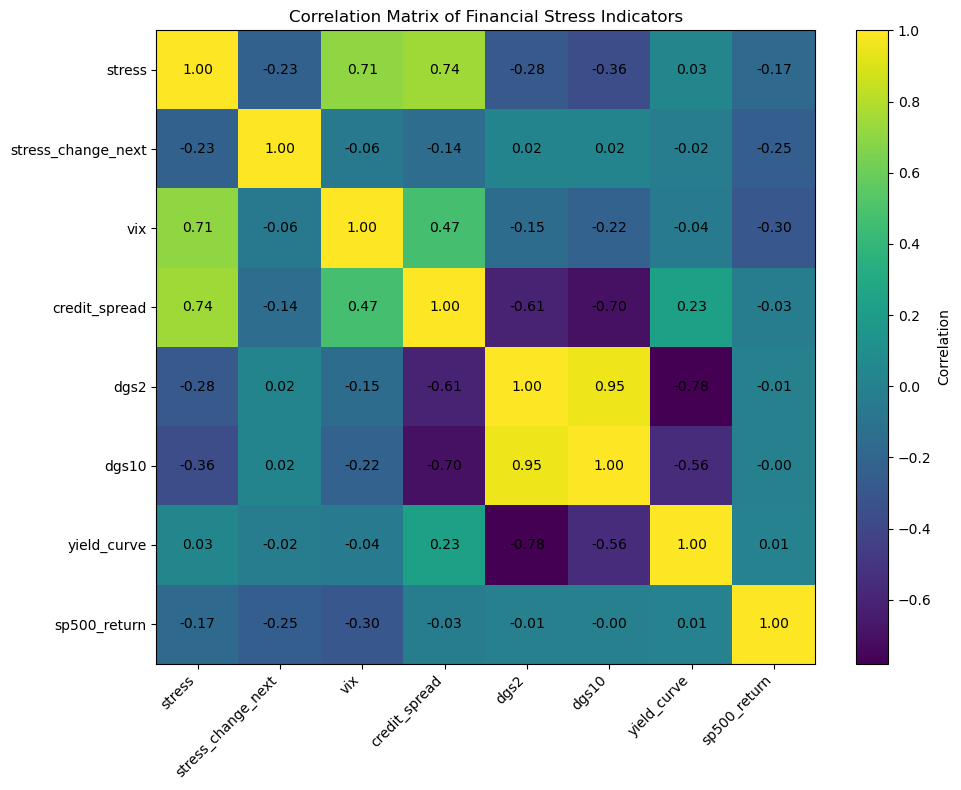

Correlations with next-week change in financial stress:


,correlation_with_stress_change_next
stress_lag1,-0.291995
vix_lag1,-0.206983
vix_lag4,-0.191155
credit_spread_lag1,-0.187000
stress_lag4,-0.183085
sp500_return_4w_mean,0.163505
sp500_return_lag1,0.163369
sp500_abs_return_4w_mean,-0.142006
credit_spread_lag4,-0.102007
sp500_return_lag4,0.080999


In [4]:
# Correlation matrix and channel relationship analysis

corr_cols = [
    "stress",
    "stress_change_next",
    "vix",
    "credit_spread",
    "dgs2",
    "dgs10",
    "yield_curve",
    "sp500_return"
]

corr_matrix = df[corr_cols].corr()

display(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix of Financial Stress Indicators")
plt.tight_layout()
plt.show()

lag_corr_cols = [
    "stress_lag1",
    "stress_lag4",
    "vix_lag1",
    "vix_lag4",
    "credit_spread_lag1",
    "credit_spread_lag4",
    "dgs2_lag1",
    "dgs2_lag4",
    "dgs10_lag1",
    "dgs10_lag4",
    "yield_curve_lag1",
    "yield_curve_lag4",
    "sp500_return_lag1",
    "sp500_return_lag4",
    "sp500_return_4w_mean",
    "sp500_abs_return_4w_mean"
]

target_corr = (
    df[lag_corr_cols + ["stress_change_next"]]
    .corr()["stress_change_next"]
    .drop("stress_change_next")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Correlations with next-week change in financial stress:")
display(target_corr.to_frame("correlation_with_stress_change_next"))

## Correlation Matrix Interpretation

The correlation matrix shows that the official financial stress index is most strongly associated with VIX and the Baa corporate credit spread. The correlation between financial stress and VIX is approximately 0.71, while the correlation between financial stress and the credit spread is approximately 0.74. This suggests that equity volatility and credit-market stress are the two strongest contemporaneous stress channels in the dataset.

The Baa credit spread is slightly more correlated with the stress index than VIX, which suggests that credit-market conditions may be especially important in explaining broad financial stress. However, this does not prove that credit spreads lead future stress changes. It only shows that credit spreads and financial stress move together strongly over the sample.

Treasury yields have negative correlations with the financial stress index. The 2-year Treasury yield has a correlation of about -0.28 with stress, while the 10-year Treasury yield has a correlation of about -0.36. This is consistent with risk-off periods in which Treasury yields fall during periods of financial stress due to safe-haven demand or expectations of easier monetary policy.

The 10Y–2Y yield spread has a weak contemporaneous correlation with financial stress, near 0.03. This suggests that the yield curve may not explain short-run stress levels directly in this sample, although it may still provide useful information in lagged or multivariate models.

S&P 500 weekly returns have a negative relationship with future stress changes. The correlation between S&P 500 weekly returns and `stress_change_next` is approximately -0.25, indicating that weaker equity-market performance is associated with future increases in financial stress.

The Treasury yield variables are highly correlated with each other. The 2-year and 10-year Treasury yields have a correlation of approximately 0.95, which indicates strong redundancy between these rate variables. This may create multicollinearity in linear models such as ARIMAX or VAR, so the interpretation of individual Treasury-yield coefficients should be handled carefully.

The lagged predictor correlations with `stress_change_next` are generally modest. This confirms that forecasting changes in financial stress is more difficult than explaining the stress level itself. The negative correlations between lagged stress, lagged VIX, lagged credit spreads, and future stress changes suggest some mean-reversion behavior: after stress-related variables become elevated, the next change in stress may often move downward rather than continue rising.

Overall, the correlation results support the use of multiple stress channels in the forecasting models. VIX and credit spreads appear most closely related to the stress index, S&P 500 returns appear relevant for future stress changes, and Treasury variables may provide macro-financial context rather than the strongest direct short-horizon signal.

# Stationarity and Dependence Diagnostics

Before fitting ARIMA, ARIMAX, VAR, Random Forest, or XGBoost models, the target variables must be checked for persistence and stationarity. This section focuses on the official financial stress index level and the next-week change in financial stress.

The stress level is expected to be persistent because financial stress conditions tend to carry over from one week to the next. The stress-change series is expected to be less persistent because it measures acceleration or reversal in stress rather than the level itself.

The diagnostics include ACF and PACF plots to examine serial dependence, along with ADF and KPSS tests to evaluate stationarity. These checks help determine whether ARIMA-style models should be applied to the stress level, the stress-change target, or both.

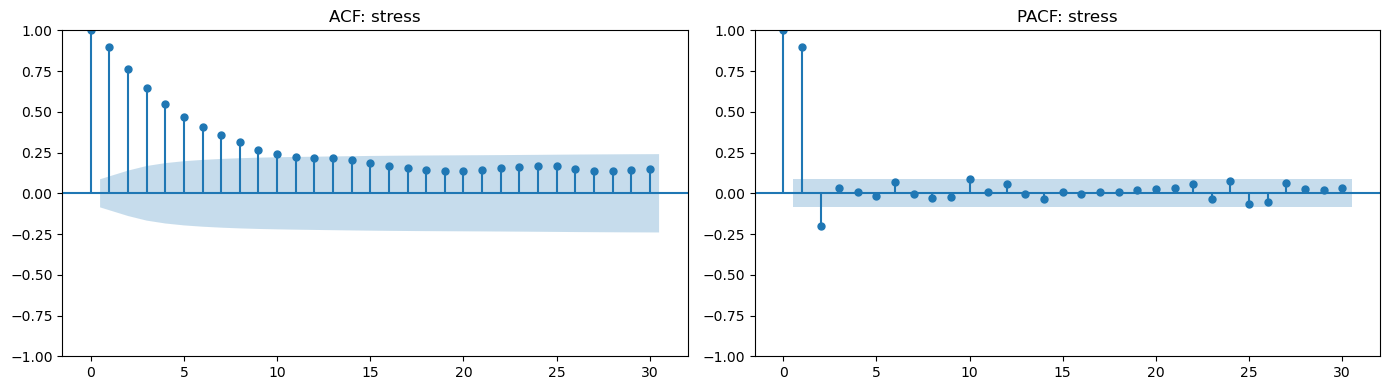

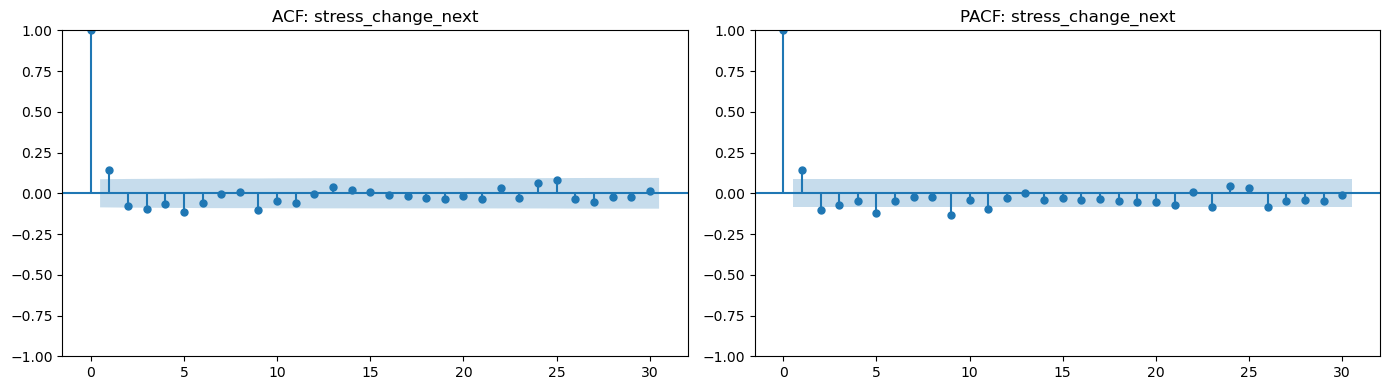

,variable,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue,interpretation
0,stress,-6.319363,3.093366e-08,0.477817,0.046663,Mixed evidence
1,stress_change_next,-9.605167,1.874625e-16,0.014509,0.100000,Stationary by ADF and KPSS


In [5]:
# Stationarity and dependence diagnostics

import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning

target_cols = ["stress", "stress_change_next"]

for col in target_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    plot_acf(df[col], lags=30, ax=axes[0])
    axes[0].set_title(f"ACF: {col}")
    
    plot_pacf(df[col], lags=30, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF: {col}")
    
    plt.tight_layout()
    plt.show()

def stationarity_tests(series, name):
    series = series.dropna()
    
    adf_result = adfuller(series, autolag="AIC")
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_result = kpss(series, regression="c", nlags="auto")
    
    adf_pvalue = adf_result[1]
    kpss_pvalue = kpss_result[1]
    
    if adf_pvalue < 0.05 and kpss_pvalue > 0.05:
        interpretation = "Stationary by ADF and KPSS"
    elif adf_pvalue >= 0.05 and kpss_pvalue <= 0.05:
        interpretation = "Likely nonstationary"
    else:
        interpretation = "Mixed evidence"
    
    return {
        "variable": name,
        "adf_stat": adf_result[0],
        "adf_pvalue": adf_pvalue,
        "kpss_stat": kpss_result[0],
        "kpss_pvalue": kpss_pvalue,
        "interpretation": interpretation
    }

stationarity_results = pd.DataFrame([
    stationarity_tests(df["stress"], "stress"),
    stationarity_tests(df["stress_change_next"], "stress_change_next")
])

display(stationarity_results)

## Stationarity and Dependence Diagnostics Interpretation

The ACF and PACF plots examine whether the financial stress target variables are dependent on their own past values. Because the dataset is weekly, lag 1 represents one week earlier, lag 2 represents two weeks earlier, and lag 4 represents roughly one month earlier.

The ACF plot for `stress` shows a slow decay across many lags. This means the financial stress level is highly persistent: if stress is elevated this week, it tends to remain related to stress levels several weeks later. This slow decay is a sign of strong serial dependence and possible borderline stationarity. It does not automatically prove nonstationarity, but it shows that the stress level is heavily influenced by its own history.

The PACF plot for `stress` shows a large first-lag effect and then much smaller effects after the first few lags. This means last week’s stress level has the strongest direct relationship with this week’s stress level after accounting for other short-lag effects. This supports using ARIMA-style models as a benchmark because ARIMA models are designed to capture autoregressive dependence in the target series.

The ACF plot for `stress_change_next` behaves very differently. Its autocorrelations drop off quickly and remain much closer to zero. This means weekly changes in financial stress are much less persistent than the stress level itself. In other words, changes in stress are not as mechanically tied to their own past as the stress level is.

The PACF plot for `stress_change_next` also shows weaker lag structure. This suggests there is limited direct autoregressive dependence in stress changes. This is important for the project because `stress_change_next` is less dominated by persistence, making it a stronger target for testing whether market indicators such as VIX, credit spreads, Treasury yields, the yield curve, and equity returns add forecasting value.

The ADF and KPSS tests support this interpretation. The stress level shows mixed or borderline stationarity evidence, while `stress_change_next` is more clearly stationary. Overall, the diagnostics suggest that the stress level is useful for ARIMA benchmarking, while stress change is the better primary target for channel-ranking and stress-acceleration forecasting.

# Stationarity Checks for Modeling Variables

The previous diagnostics focused on the two target variables: the financial stress level and the next-week change in financial stress. This section extends the stationarity checks to the main variables that may be used in ARIMAX, VAR, Random Forest, and XGBoost models.

The purpose is not to produce ACF and PACF plots for every predictor. Instead, the goal is to identify whether any variables show clear nonstationarity before they are used in linear time-series models. This matters most for ARIMAX and VAR, where persistent or nonstationary predictors can affect model interpretation.

Tree-based models such as Random Forest and XGBoost are less restricted by stationarity assumptions, but the stationarity checks still help explain the time-series behavior of the predictor variables.

In [6]:
# Stationarity checks for modeling variables

model_check_cols = [
    "stress",
    "stress_change_next",
    "vix",
    "credit_spread",
    "dgs2",
    "dgs10",
    "yield_curve",
    "sp500_return"
]

stationarity_rows = []

for col in model_check_cols:
    result = stationarity_tests(df[col], col)
    stationarity_rows.append(result)

stationarity_all = pd.DataFrame(stationarity_rows)

display(stationarity_all)

,variable,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue,interpretation
0,stress,-6.319363,3.093366e-08,0.477817,0.046663,Mixed evidence
1,stress_change_next,-9.605167,1.874625e-16,0.014509,0.100000,Stationary by ADF and KPSS
2,vix,-5.816107,4.288810e-07,0.519665,0.037238,Mixed evidence
3,credit_spread,-2.917666,4.333187e-02,1.251258,0.010000,Mixed evidence
4,dgs2,-1.172873,6.851550e-01,1.713685,0.010000,Likely nonstationary
5,dgs10,-0.913614,7.834561e-01,1.817508,0.010000,Likely nonstationary
6,yield_curve,-1.521030,5.230836e-01,0.891211,0.010000,Likely nonstationary
7,sp500_return,-11.651886,2.028049e-21,0.056881,0.100000,Stationary by ADF and KPSS


# Stationarity Checks for Modeling Variables: Interpretation

The stationarity checks extend the target-variable diagnostics to the main variables used in the forecasting models. This step is especially important for ARIMAX and VAR because linear time-series models are more sensitive to persistent or nonstationary variables. Random Forest and XGBoost are less restricted by stationarity assumptions, but these tests still help explain the behavior of the predictor series.

The stress level shows mixed stationarity evidence. The ADF test rejects the unit-root null, but the KPSS test is borderline, suggesting that the stress level is persistent and should be interpreted carefully in level form. This is consistent with the ACF results, where financial stress showed slow decay over multiple lags.

The stress-change target is stationary by both ADF and KPSS. This supports using `stress_change_next` as the primary modeling target because it is less dominated by persistence and better represents short-run acceleration or reversal in financial stress.

VIX and the Baa credit spread show mixed evidence. Both have ADF p-values below 0.05, but their KPSS p-values reject stationarity. This suggests that these variables may be persistent or regime-dependent even if they do not behave like pure unit-root processes. They remain important stress-channel predictors, but model interpretation should recognize that they can shift across market regimes.

The Treasury yield variables show the clearest nonstationarity concerns. The 2-year Treasury yield, 10-year Treasury yield, and 10Y–2Y yield spread all have high ADF p-values and low KPSS p-values, indicating likely nonstationarity in level form. This matters most for VAR and ARIMAX interpretation. These rate variables may need to be differenced or handled through a reduced specification before final linear modeling.

S&P 500 weekly returns are stationary by both ADF and KPSS. This is expected because returns are usually more stationary than price levels. The return series can be used directly as an equity-market performance predictor.

Overall, these results suggest that `stress_change_next` and S&P 500 returns are suitable in their current form, while Treasury yield variables require caution in linear time-series models. For VAR, the safer approach is to use stationary transformations, such as changes in Treasury yields and changes in the yield spread, rather than relying only on rate levels.

## Create First-Difference Variables for Nonstationary Predictors

The stationarity checks showed that several predictor variables were not clearly stationary in level form. The Treasury yield variables (`dgs2`, `dgs10`) and the yield-curve spread (`yield_curve`) showed likely nonstationarity, while VIX and the credit spread showed mixed evidence. This matters most for linear time-series models such as ARIMAX and VAR because persistent or nonstationary predictors can make coefficient interpretation unstable.

To address this, first-difference variables are created for the main market channels. These variables measure weekly changes rather than levels. Because the dataset is weekly, a first difference measures how much a variable changed from the previous week to the current week.

For example:

`dgs2_change = dgs2_t - dgs2_{t-1}`

This means the weekly change in the 2-year Treasury yield. If `dgs2_change` is positive, the 2-year Treasury yield increased from the prior week. If it is negative, the 2-year Treasury yield decreased from the prior week.

These transformed variables are mainly used for VAR, ARIMAX robustness checks, and lead-lag diagnostics. Random Forest and XGBoost are less restricted by formal stationarity assumptions, so the original lagged level variables can still be useful for those models.

In [7]:
# Create stationary change variables for modeling diagnostics

df["vix_change"] = df["vix"] - df["vix_lag1"]
df["credit_spread_change"] = df["credit_spread"] - df["credit_spread_lag1"]
df["dgs2_change"] = df["dgs2"] - df["dgs2_lag1"]
df["dgs10_change"] = df["dgs10"] - df["dgs10_lag1"]
df["yield_curve_change"] = df["yield_curve"] - df["yield_curve_lag1"]

change_cols = [
    "stress_change_next",
    "vix_change",
    "credit_spread_change",
    "dgs2_change",
    "dgs10_change",
    "yield_curve_change",
    "sp500_return"
]

stationarity_change_rows = []

for col in change_cols:
    result = stationarity_tests(df[col], col)
    stationarity_change_rows.append(result)

stationarity_changes = pd.DataFrame(stationarity_change_rows)

display(stationarity_changes)

,variable,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue,interpretation
0,stress_change_next,-9.605167,1.874625e-16,0.014509,0.1,Stationary by ADF and KPSS
1,vix_change,-9.916109,3.077047e-17,0.019400,0.1,Stationary by ADF and KPSS
2,credit_spread_change,-13.037873,2.273272e-24,0.038791,0.1,Stationary by ADF and KPSS
3,dgs2_change,-9.730334,9.040210e-17,0.166065,0.1,Stationary by ADF and KPSS
4,dgs10_change,-23.417402,0.000000e+00,0.121820,0.1,Stationary by ADF and KPSS
5,yield_curve_change,-9.820674,5.348686e-17,0.161092,0.1,Stationary by ADF and KPSS
6,sp500_return,-11.651886,2.028049e-21,0.056881,0.1,Stationary by ADF and KPSS


## First-Difference Stationarity Interpretation

The first-difference stationarity results show that the transformed variables are stationary by both ADF and KPSS. This is important because the earlier stationarity checks indicated likely nonstationarity for the Treasury yield variables and the yield-curve spread, along with mixed evidence for VIX and the credit spread.

After converting these variables into weekly changes, the ADF p-values are below 0.05 and the KPSS p-values are above 0.05. This means the transformed variables reject the unit-root null under ADF and fail to reject stationarity under KPSS.

The practical interpretation is that weekly changes in VIX, credit spreads, Treasury yields, and the yield curve are more stable for linear time-series modeling than their raw levels. This supports using the change variables in VAR and ARIMAX-style analysis where stationarity matters most.

The original level variables are still useful for exploratory analysis and tree-based models, but the transformed variables provide a cleaner input set for models that rely more heavily on stable time-series relationships.

# Cross-Correlation and Lead-Lag Analysis

This section examines whether market-based stress indicators tend to move before future changes in the official financial stress index. The goal is to identify whether volatility, credit, equity, and rate/yield-curve channels are mostly coincident with financial stress changes or whether one channel shows a stronger leading relationship.

The analysis compares each market indicator at lags 0 through 4 with `stress_change_next`, the primary forecasting target. Because `stress_change_next` already measures next week’s change in financial stress, a lag of 0 means the current week’s market indicator is being compared with next week’s stress change. A lag of 1 means the indicator from one week earlier is being compared with next week’s stress change, and lag 4 represents information from roughly one month earlier.

This analysis supports the channel-ranking and lead-lag research questions. It helps determine whether the strongest exploratory signals come from VIX, credit spreads, S&P 500 returns, Treasury-yield changes, or yield-curve changes. It also helps identify whether the strongest relationships are immediate or delayed.

This is not a causal test and does not replace ARIMAX, VAR, Random Forest, or XGBoost modeling. It is an exploratory diagnostic used to guide interpretation before formal forecasting models are fitted.

,channel,predictor_lag_weeks,correlation,abs_correlation
0,VIX change,0,0.298644,0.298644
1,S&P 500 return,0,-0.248658,0.248658
2,Credit spread change,0,0.213805,0.213805
3,VIX level,1,-0.206946,0.206946
4,VIX level,3,-0.196950,0.196950
5,VIX level,4,-0.190129,0.190129
6,Credit spread level,1,-0.188114,0.188114
7,Credit spread change,1,-0.175425,0.175425
8,VIX level,2,-0.173549,0.173549
9,S&P 500 return,1,0.163315,0.163315


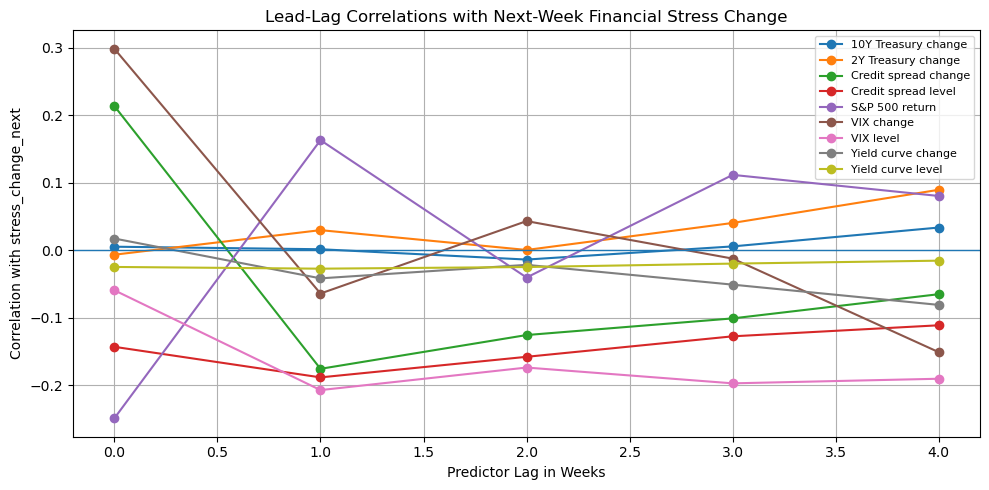

In [8]:
# Cross-correlation and Lead-Lag analysis

lead_lag_vars = {
    "VIX level": "vix",
    "VIX change": "vix_change",
    "Credit spread level": "credit_spread",
    "Credit spread change": "credit_spread_change",
    "2Y Treasury change": "dgs2_change",
    "10Y Treasury change": "dgs10_change",
    "Yield curve level": "yield_curve",
    "Yield curve change": "yield_curve_change",
    "S&P 500 return": "sp500_return"
}

lead_lag_rows = []

for label, col in lead_lag_vars.items():
    for lag in range(0, 5):
        shifted_predictor = df[col].shift(lag)
        corr_value = shifted_predictor.corr(df["stress_change_next"])
        
        lead_lag_rows.append({
            "channel": label,
            "predictor_lag_weeks": lag,
            "correlation": corr_value,
            "abs_correlation": abs(corr_value)
        })

lead_lag_corr = pd.DataFrame(lead_lag_rows)

lead_lag_corr_sorted = (
    lead_lag_corr
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

display(lead_lag_corr_sorted)

plot_table = lead_lag_corr.pivot(
    index="predictor_lag_weeks",
    columns="channel",
    values="correlation"
)

plt.figure(figsize=(10, 5))

for col in plot_table.columns:
    plt.plot(plot_table.index, plot_table[col], marker="o", label=col)

plt.axhline(0, linewidth=1)
plt.title("Lead-Lag Correlations with Next-Week Financial Stress Change")
plt.xlabel("Predictor Lag in Weeks")
plt.ylabel("Correlation with stress_change_next")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

## Cross-Correlation and Lead-Lag Interpretation

The lead-lag results show that the strongest exploratory relationship with next-week financial stress changes comes from the current-week change in VIX. The correlation between `vix_change` at lag 0 and `stress_change_next` is approximately 0.30. This suggests that sharp weekly increases in equity volatility are associated with increases in financial stress in the following week.

The second strongest relationship is the current-week S&P 500 return, with a correlation of approximately -0.25. The negative sign means that weaker equity returns are associated with higher next-week financial stress changes. This supports the idea that equity-market deterioration is an important short-horizon stress signal.

The current-week change in the credit spread also has a positive correlation of approximately 0.21 with next-week stress changes. This means that widening credit spreads are associated with future increases in financial stress. Together, the VIX-change and credit-spread-change results suggest that changes in market risk conditions may be more informative for short-horizon stress acceleration than some raw level variables.

The VIX level and credit-spread level show mostly negative lagged correlations with `stress_change_next`. This does not mean that VIX or credit spreads are unrelated to stress. Earlier correlation results showed that both are strongly related to the stress level. The negative lagged relationship with stress changes likely reflects mean reversion: after volatility or credit spreads are already elevated, the next weekly change in stress may often be flat or declining rather than continuing upward.

Treasury-yield changes and yield-curve variables show much weaker correlations with `stress_change_next`. This suggests that interest-rate and yield-curve variables may provide broader macro-financial context, but they are not the strongest short-horizon signals for weekly stress acceleration in this sample.

Overall, the lead-lag results suggest that the strongest near-term signals for next-week financial stress changes come from equity volatility changes, S&P 500 returns, and credit-spread changes. The relationships are still modest, so the results should not be overinterpreted as standalone predictive evidence. Instead, they provide support for the next modeling stage, where ARIMAX, VAR, Random Forest, and XGBoost will test whether these channels improve out-of-sample forecasting performance.

# Train/Test Split and Model Feature Setup

The next step is to define the modeling target, predictor variables, and chronological train/test split. Because this is a time-series forecasting project, the data must be split by time rather than randomly. A random split would leak future information into the training process and produce misleading model performance.

The primary target is `stress_change_next`, which measures the next-week change in the official financial stress index. This target is used because it focuses on stress acceleration and reversal rather than simply forecasting the persistent level of financial stress.

The secondary target is `stress_next`, which measures the next-week level of the financial stress index. This target is retained for comparison, but the main interpretation focuses on stress-change forecasting.

The feature set includes current financial stress, lagged stress, lagged market indicators, weekly market changes, and equity-return features. Current-week stress is included because it is known at the time of prediction and may help capture mean-reversion behavior. All predictors are constructed so that information available at or before week `t` is used to forecast financial stress changes in week `t+1`.

A high-stress-acceleration threshold is also defined using the training set only. This threshold identifies weeks where next-week financial stress increased sharply. It will later be used to evaluate whether Random Forest and XGBoost reduce forecast error specifically during the weeks that matter most.

In [12]:
# Train/test split and model feature setup

target_col = "stress_change_next"
secondary_target_col = "stress_next"

feature_cols = [
    "stress",
    "stress_lag1",
    "stress_lag4",
    "vix_lag1",
    "vix_lag4",
    "credit_spread_lag1",
    "credit_spread_lag4",
    "dgs2_lag1",
    "dgs2_lag4",
    "dgs10_lag1",
    "dgs10_lag4",
    "yield_curve_lag1",
    "yield_curve_lag4",
    "sp500_return_lag1",
    "sp500_return_lag4",
    "sp500_return_4w_mean",
    "sp500_abs_return_4w_mean",
    "vix_change",
    "credit_spread_change",
    "dgs2_change",
    "dgs10_change",
    "yield_curve_change",
    "sp500_return"
]

model_df = df[["date", target_col, secondary_target_col] + feature_cols].copy()

# Chronological 80/20 split
split_idx = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Define high-stress-acceleration weeks using training-set threshold only
high_stress_threshold = y_train.quantile(0.75)

train_df["high_stress_acceleration"] = train_df[target_col] >= high_stress_threshold
test_df["high_stress_acceleration"] = test_df[target_col] >= high_stress_threshold

print("Modeling dataset shape:", model_df.shape)
print("Training set:", train_df["date"].min(), "to", train_df["date"].max(), "| rows:", train_df.shape[0])
print("Testing set:", test_df["date"].min(), "to", test_df["date"].max(), "| rows:", test_df.shape[0])

print("\nTarget variable:", target_col)
print("Secondary target:", secondary_target_col)

print("\nHigh-stress-acceleration threshold:")
print(high_stress_threshold)

print("\nHigh-stress-acceleration counts:")
print("Train:", train_df["high_stress_acceleration"].sum(), "of", train_df.shape[0])
print("Test:", test_df["high_stress_acceleration"].sum(), "of", test_df.shape[0])

print("\nMissing values in modeling dataset:")
display(model_df.isna().sum())

display(model_df.head())
display(model_df.tail())

Modeling dataset shape: (516, 26)
Training set: 2016-06-03 00:00:00 to 2024-04-19 00:00:00 | rows: 412
Testing set: 2024-04-26 00:00:00 to 2026-04-17 00:00:00 | rows: 104

Target variable: stress_change_next
Secondary target: stress_next

High-stress-acceleration threshold:
0.09874999999999992

High-stress-acceleration counts:
Train: 103 of 412
Test: 27 of 104

Missing values in modeling dataset:


date                        0
stress_change_next          0
stress_next                 0
stress                      0
stress_lag1                 0
stress_lag4                 0
vix_lag1                    0
vix_lag4                    0
credit_spread_lag1          0
credit_spread_lag4          0
dgs2_lag1                   0
dgs2_lag4                   0
dgs10_lag1                  0
dgs10_lag4                  0
yield_curve_lag1            0
yield_curve_lag4            0
sp500_return_lag1           0
sp500_return_lag4           0
sp500_return_4w_mean        0
sp500_abs_return_4w_mean    0
vix_change                  0
credit_spread_change        0
dgs2_change                 0
dgs10_change                0
yield_curve_change          0
sp500_return                0
dtype: int64

,date,stress_change_next,stress_next,stress,stress_lag1,stress_lag4,vix_lag1,vix_lag4,credit_spread_lag1,credit_spread_lag4,...,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean,vix_change,credit_spread_change,dgs2_change,dgs10_change,yield_curve_change,sp500_return
0,2016-06-03,0.0268,0.1522,0.1254,-0.0029,0.2686,13.12,14.72,2.85,2.87,...,0.022519,-0.011738,0.002109,0.010544,0.35,0.01,-0.12,-0.14,-0.02,0.001034
1,2016-06-10,0.4147,0.5669,0.1522,0.1254,0.1787,13.47,15.04,2.86,2.90,...,0.001034,-0.005132,0.005302,0.007868,3.56,0.00,-0.05,-0.07,-0.02,-0.001459
2,2016-06-17,-0.3097,0.2572,0.5669,0.1522,0.0768,17.03,15.20,2.86,2.86,...,-0.001459,0.002786,0.006220,0.006949,2.38,0.03,-0.03,-0.02,0.01,-0.011926
3,2016-06-24,0.3235,0.5807,0.2572,0.5669,-0.0029,19.41,13.12,2.89,2.85,...,-0.011926,0.022519,0.002542,0.009235,6.35,0.09,-0.06,-0.05,0.01,-0.016458
4,2016-07-01,-0.3756,0.2051,0.5807,0.2572,0.1254,25.76,13.47,2.98,2.86,...,-0.016458,0.001034,-0.007202,0.007719,-10.99,-0.12,-0.05,-0.11,-0.06,0.031662


,date,stress_change_next,stress_next,stress,stress_lag1,stress_lag4,vix_lag1,vix_lag4,credit_spread_lag1,credit_spread_lag4,...,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean,vix_change,credit_spread_change,dgs2_change,dgs10_change,yield_curve_change,sp500_return
511,2026-03-20,0.1854,-0.1804,-0.3658,-0.2972,-0.4875,27.19,19.09,1.83,1.69,...,-0.016128,0.009640,-0.007831,0.012651,-0.41,-0.04,0.15,0.11,-0.04,-0.019136
512,2026-03-27,-0.0600,-0.2404,-0.1804,-0.3658,-0.4423,26.78,19.86,1.79,1.80,...,-0.019136,-0.004443,-0.015025,0.015025,4.27,-0.01,0.00,0.05,0.05,-0.021380
513,2026-04-03,-0.4068,-0.6472,-0.2404,-0.1804,-0.4272,31.05,29.49,1.78,1.75,...,-0.021380,-0.020393,-0.019259,0.019259,-7.18,-0.04,-0.04,-0.09,-0.05,0.033025
514,2026-04-10,-0.1108,-0.7580,-0.6472,-0.2404,-0.2972,23.87,27.19,1.74,1.83,...,0.033025,-0.016128,-0.005905,0.022417,-4.64,-0.02,-0.03,-0.04,-0.01,0.030543
515,2026-04-17,0.0798,-0.6782,-0.7580,-0.6472,-0.3658,19.23,26.78,1.72,1.79,...,0.030543,-0.019136,0.005763,0.026021,-1.75,0.00,-0.10,-0.05,0.05,0.044355


# Baseline Forecasting Models

The first modeling step establishes simple benchmark forecasts for the primary target, `stress_change_next`. These baselines are used to determine whether more complex models actually add forecasting value.

The main baseline is a no-change forecast. Since `stress_change_next` measures the next-week change in financial stress, predicting zero means assuming that financial stress will remain unchanged next week. This is a natural benchmark because the stress-change series is centered near zero and has weaker persistence than the stress level.

A second baseline uses the historical training mean of `stress_change_next`. This checks whether a simple average-change forecast performs similarly to the no-change forecast.

All later models, including ARIMA, ARIMAX, VAR, Random Forest, and XGBoost, should be compared against these baseline forecasts.

,model,rmse,mae,directional_accuracy,high_stress_rmse,high_stress_mae
0,Naive no-change baseline,0.198906,0.135457,0.000000,0.254817,0.214300
1,Training mean baseline,0.198938,0.135845,0.423077,0.256793,0.216645


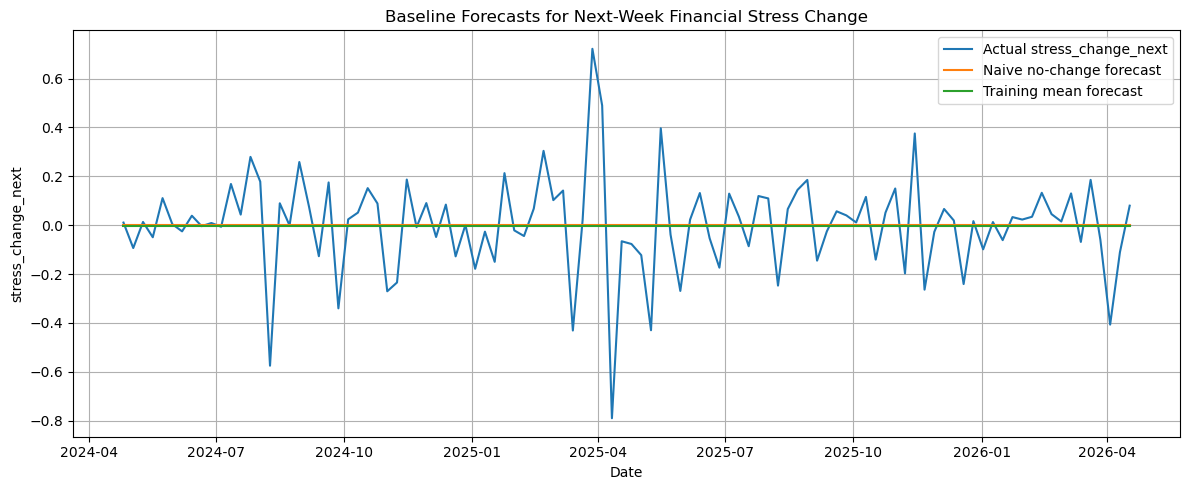

In [14]:
# Baseline forecasting models

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate_forecast(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    
    high_stress_mask = test_df["high_stress_acceleration"].values
    
    high_stress_rmse = np.sqrt(mean_squared_error(
        y_true[high_stress_mask],
        y_pred[high_stress_mask]
    ))
    
    high_stress_mae = mean_absolute_error(
        y_true[high_stress_mask],
        y_pred[high_stress_mask]
    )
    
    return {
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "directional_accuracy": directional_accuracy,
        "high_stress_rmse": high_stress_rmse,
        "high_stress_mae": high_stress_mae
    }

# Baseline 1: no-change forecast
naive_zero_pred = np.zeros(len(y_test))

# Baseline 2: training mean forecast
train_mean_pred = np.full(len(y_test), y_train.mean())

baseline_results = pd.DataFrame([
    evaluate_forecast(y_test.values, naive_zero_pred, "Naive no-change baseline"),
    evaluate_forecast(y_test.values, train_mean_pred, "Training mean baseline")
])

display(baseline_results)


# Plot baseline forecasts
plt.figure(figsize=(12, 5))

plt.plot(test_df["date"], y_test.values, label="Actual stress_change_next")
plt.plot(test_df["date"], naive_zero_pred, label="Naive no-change forecast")
plt.plot(test_df["date"], train_mean_pred, label="Training mean forecast")

plt.title("Baseline Forecasts for Next-Week Financial Stress Change")
plt.xlabel("Date")
plt.ylabel("stress_change_next")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Baseline Forecasting Interpretation

The baseline models establish the minimum performance that later models need to beat. The no-change baseline predicts that next week's change in financial stress will be zero, while the training-mean baseline predicts the average stress change observed in the training period.

Both baseline models produce very similar overall performance. The training-mean baseline has a slightly lower RMSE and MAE than the no-change baseline, but the improvement is extremely small. This suggests that the test-period stress-change series is centered near zero and that simple average-change forecasts are difficult to beat by a large margin.

The baseline plot is expected to show flat forecast lines near zero. The no-change baseline is exactly zero for every test observation, while the training-mean forecast is nearly zero because the average weekly stress change in the training data is close to zero. This is why the two baseline forecast lines overlap visually.

The no-change baseline has a directional accuracy of zero because it always predicts exactly zero. Since the actual stress-change values are usually positive or negative rather than exactly zero, the sign-based directional accuracy calculation does not credit the no-change forecast as predicting either direction. The training-mean baseline has positive directional accuracy because it always predicts the sign of the historical average stress change.

During high-stress-acceleration weeks, the no-change baseline has slightly lower high-stress RMSE and MAE than the training-mean baseline. This gives later models a clear benchmark: a model must reduce error not only on average, but also during weeks when financial stress is rising sharply.

Overall, the baseline results show that forecasting weekly stress changes is difficult. Later models need to demonstrate whether lagged stress, volatility, credit spreads, rates, yield-curve variables, and equity returns provide enough signal to improve on these simple benchmarks.

# ARIMA Benchmark Model

The first formal forecasting model is ARIMA, a classical univariate time-series model. In this section, ARIMA is used to forecast `stress_change_next` using only the past behavior of the stress-change series itself.

This model serves as the main statistical benchmark before adding external market indicators. If ARIMA performs well, it suggests that next-week changes in financial stress are partly explained by their own recent history. If ARIMA performs poorly relative to ARIMAX, VAR, Random Forest, or XGBoost, then the market-based predictors may contain additional useful forecasting information.

Because the earlier stationarity checks showed that `stress_change_next` is stationary, the ARIMA model is estimated with `d = 0`. The model-selection step compares several ARMA-style specifications using AIC, then the selected model is evaluated on the chronological test set using rolling one-step-ahead forecasts.

The ARIMA workflow is:

- Select the ARIMA order using training-set AIC.
- Fit the final ARIMA model on the training target.
- Review the model summary.
- Check residual autocorrelation using residual ACF and the Ljung-Box test.
- Generate rolling one-step-ahead forecasts on the test period.
- Compare RMSE, MAE, directional accuracy, and high-stress-week performance against the baseline models.

In [15]:
# ARIMA model selection

import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

arima_orders = []

for p in range(0, 5):
    for q in range(0, 5):
        order = (p, 0, q)
        
        try:
            model = SARIMAX(
                y_train,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            result = model.fit(disp=False)
            
            arima_orders.append({
                "order": order,
                "aic": result.aic,
                "bic": result.bic
            })
            
        except Exception:
            continue

arima_order_results = (
    pd.DataFrame(arima_orders)
    .sort_values("aic")
    .reset_index(drop=True)
)

display(arima_order_results.head(10))

best_arima_order = arima_order_results.loc[0, "order"]

print("Selected ARIMA order:", best_arima_order)

,order,aic,bic
0,"(1, 0, 2)",124.441260,144.509836
1,"(1, 0, 4)",125.002841,153.064533
2,"(1, 0, 3)",125.006016,149.073619
3,"(3, 0, 2)",125.552587,153.648593
4,"(2, 0, 3)",125.911745,153.990616
5,"(2, 0, 2)",126.351893,150.434183
6,"(2, 0, 1)",127.073456,147.154241
7,"(4, 0, 2)",127.630414,159.720551
8,"(2, 0, 4)",128.043870,160.114376
9,"(3, 0, 4)",128.445898,164.525217


Selected ARIMA order: (1, 0, 2)


## ARIMA Model Selection Interpretation

The ARIMA order-selection step compared ARIMA models with `d = 0` across different autoregressive and moving-average orders. The differencing parameter was fixed at zero because the earlier ADF and KPSS tests indicated that `stress_change_next` is stationary. Since the target already measures the one-week change in financial stress, additional differencing would model the change of the change, which would weaken the interpretation of the forecast target.

The model-selection results identify ARIMA(1, 0, 2) as the preferred specification by AIC. This means the selected ARIMA model uses one autoregressive lag and two moving-average terms to forecast next-week changes in financial stress. In this benchmark model, no external financial indicators are included; the forecast is based only on the historical behavior of `stress_change_next`.

This model provides the main univariate statistical benchmark. Later models such as ARIMAX, VAR, Random Forest, and XGBoost must show whether market-based indicators improve forecast performance beyond this target-history-only ARIMA model.

                               SARIMAX Results                                
Dep. Variable:     stress_change_next   No. Observations:                  412
Model:               SARIMAX(1, 0, 2)   Log Likelihood                 -57.221
Date:                Sun, 03 May 2026   AIC                            124.441
Time:                        14:27:58   BIC                            144.510
Sample:                             0   HQIC                           132.382
                                - 412                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0001      0.000     -0.408      0.683      -0.001       0.000
ar.L1          0.8499      0.018     46.207      0.000       0.814       0.886
ma.L1         -0.7358      5.880     -0.125      0.9

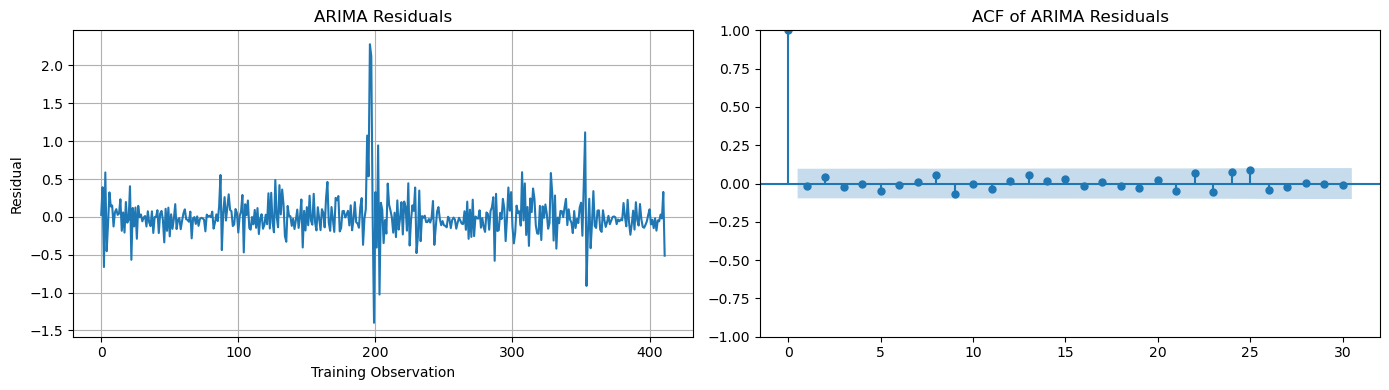

,lb_stat,lb_pvalue
10,5.428671,0.860767
20,8.602489,0.987071


In [16]:
# Fit final ARIMA model and check residual diagnostics

arima_model = SARIMAX(
    y_train,
    order=best_arima_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

arima_result = arima_model.fit(disp=False)

print(arima_result.summary())

arima_residuals = arima_result.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(arima_residuals)
axes[0].set_title("ARIMA Residuals")
axes[0].set_xlabel("Training Observation")
axes[0].set_ylabel("Residual")
axes[0].grid(True)

plot_acf(arima_residuals, lags=30, ax=axes[1])
axes[1].set_title("ACF of ARIMA Residuals")

plt.tight_layout()
plt.show()

ljung_box_arima = acorr_ljungbox(arima_residuals, lags=[10, 20], return_df=True)

display(ljung_box_arima)

## ARIMA Residual Diagnostics Interpretation

The ARIMA residual diagnostics suggest that the selected model captures most of the linear time-series dependence in `stress_change_next`. The residual ACF does not show strong remaining autocorrelation, and the Ljung-Box test p-values at lags 10 and 20 are both well above 0.05. This means there is no strong evidence that the ARIMA residuals contain remaining serial correlation.

The residual plot shows several large shocks, especially around periods of market stress. This is expected because financial stress changes can contain sudden jumps that are difficult for a univariate ARIMA model to forecast.

The model summary also indicates non-normal and heavy-tailed residuals, shown by the Jarque-Bera result and high kurtosis. This means the residuals are not normally distributed, but the primary goal of this project is out-of-sample forecasting performance rather than strict distributional inference. The residual diagnostics are acceptable for using ARIMA as a benchmark model.

,model,rmse,mae,directional_accuracy,high_stress_rmse,high_stress_mae
0,ARIMA,0.195858,0.140546,0.557692,0.243304,0.198357


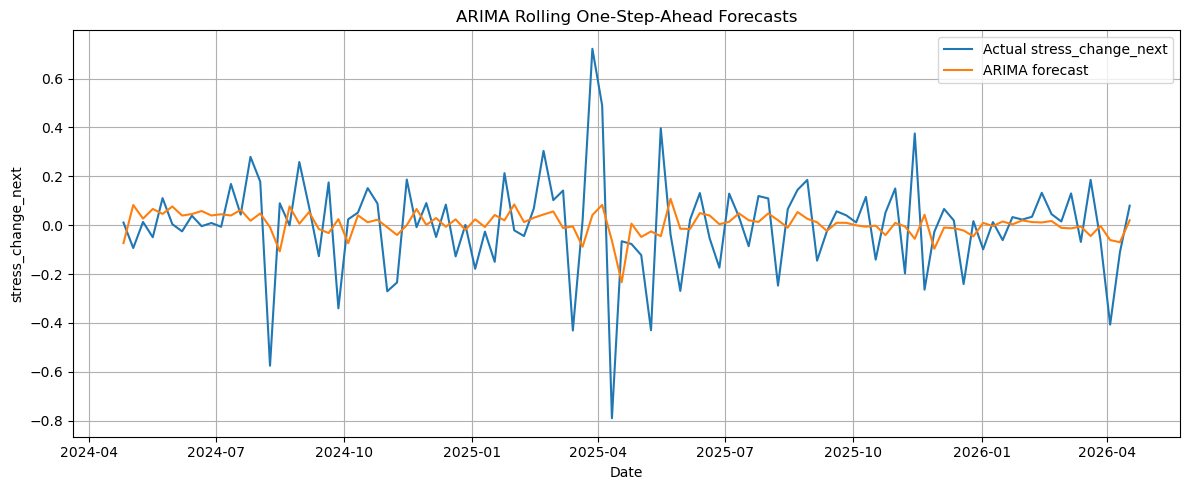

In [17]:
# Rolling one-step-ahead ARIMA forecasts

arima_history = list(y_train.values)
arima_forecasts = []

for actual in y_test.values:
    model = SARIMAX(
        arima_history,
        order=best_arima_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False)
    forecast = result.forecast(steps=1)[0]
    
    arima_forecasts.append(forecast)
    arima_history.append(actual)

arima_forecasts = np.array(arima_forecasts)

arima_results = pd.DataFrame([
    evaluate_forecast(y_test.values, arima_forecasts, "ARIMA")
])

display(arima_results)

plt.figure(figsize=(12, 5))

plt.plot(test_df["date"], y_test.values, label="Actual stress_change_next")
plt.plot(test_df["date"], arima_forecasts, label="ARIMA forecast")

plt.title("ARIMA Rolling One-Step-Ahead Forecasts")
plt.xlabel("Date")
plt.ylabel("stress_change_next")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ARIMA Forecast Evaluation Interpretation

The ARIMA model produces a test RMSE of approximately 0.196 and a MAE of approximately 0.141. Compared with the baseline models, ARIMA slightly improves RMSE but does not improve MAE. This suggests that the ARIMA model reduces some larger forecast errors but does not consistently reduce the average absolute forecast error.

The directional accuracy is approximately 0.558, meaning the model correctly predicts the sign of the next-week stress change in about 56% of test observations. This is an improvement over the baseline forecasts and suggests that the ARIMA model captures some directional movement in the stress-change series.

During high-stress-acceleration weeks, ARIMA has lower high-stress RMSE and MAE than the baseline models. This is important because the project is specifically interested in whether models can perform better during weeks when financial stress is rising sharply.

Overall, ARIMA provides a reasonable univariate benchmark. It does not dominate the simple baselines on every metric, but it improves directional accuracy and high-stress-week performance. The next step is to test whether ARIMAX can improve performance by adding external market-based predictors such as VIX, credit spreads, Treasury variables, yield-curve changes, and S&P 500 returns.

# ARIMAX Model

The next model is ARIMAX, which extends the ARIMA benchmark by adding external market-based predictors. While ARIMA forecasts `stress_change_next` using only the past behavior of the target series, ARIMAX tests whether financial-market indicators add useful forecasting information beyond the target’s own history.

This model is important for the project because it directly tests whether volatility, credit, equity, and rate/yield-curve channels improve stress-change forecasting in a classical linear time-series framework.

For ARIMAX, the predictor set is kept more controlled than the full machine-learning feature set. This is because ARIMAX is a linear model and can be affected by multicollinearity, especially among Treasury variables. The model uses current financial stress, VIX changes, credit-spread changes, S&P 500 returns, and selected rate/yield-curve change variables. These variables are designed to represent the main financial stress channels while avoiding excessive redundancy.

The ARIMAX workflow is:

- Select the ARIMAX order using training-set AIC.
- Fit the final ARIMAX model using external predictors.
- Review the model summary.
- Check residual autocorrelation using residual ACF and the Ljung-Box test.
- Generate one-step-ahead forecasts on the test period.
- Compare RMSE, MAE, directional accuracy, and high-stress-week performance against the baselines and ARIMA.

In [18]:
# ARIMAX feature setup

arimax_feature_cols = [
    "stress",
    "vix_change",
    "credit_spread_change",
    "sp500_return",
    "dgs2_change",
    "yield_curve_change"
]

X_train_arimax = train_df[arimax_feature_cols]
X_test_arimax = test_df[arimax_feature_cols]

print("ARIMAX features:")
print(arimax_feature_cols)

print("\nTraining exogenous shape:", X_train_arimax.shape)
print("Testing exogenous shape:", X_test_arimax.shape)

display(X_train_arimax.head())
display(X_train_arimax.tail())

ARIMAX features:
['stress', 'vix_change', 'credit_spread_change', 'sp500_return', 'dgs2_change', 'yield_curve_change']

Training exogenous shape: (412, 6)
Testing exogenous shape: (104, 6)


,stress,vix_change,credit_spread_change,sp500_return,dgs2_change,yield_curve_change
0,0.1254,0.35,0.01,0.001034,-0.12,-0.02
1,0.1522,3.56,0.00,-0.001459,-0.05,-0.02
2,0.5669,2.38,0.03,-0.011926,-0.03,0.01
3,0.2572,6.35,0.09,-0.016458,-0.06,0.01
4,0.5807,-10.99,-0.12,0.031662,-0.05,-0.06


,stress,vix_change,credit_spread_change,sp500_return,dgs2_change,yield_curve_change
407,-0.9419,-1.35,0.04,0.022624,-0.13,0.04
408,-0.9348,-0.05,-0.03,0.003846,0.00,-0.02
409,-0.8429,3.02,-0.01,-0.007548,0.14,0.05
410,-0.7936,1.28,-0.04,-0.015673,0.15,-0.04
411,-0.4146,1.40,0.01,-0.030958,0.09,0.03


## ARIMAX Feature Setup Note

The ARIMAX feature set uses a controlled group of external predictors rather than the full machine-learning feature set. This is intentional because ARIMAX is a linear model and can be affected by multicollinearity, especially among Treasury yield variables.

The selected predictors represent the main financial stress channels: current financial stress, equity volatility changes, credit-spread changes, S&P 500 returns, short-rate changes, and yield-curve changes. Current financial stress is included because it is known at the time of forecasting and can help capture mean-reversion behavior in next-week stress changes.

This feature set allows ARIMAX to test whether market-based indicators improve forecasting beyond the univariate ARIMA benchmark while keeping the model interpretable.

In [19]:
# ARIMAX model selection

arimax_orders = []

for p in range(0, 4):
    for q in range(0, 4):
        order = (p, 0, q)
        
        try:
            model = SARIMAX(
                y_train,
                exog=X_train_arimax,
                order=order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            
            result = model.fit(disp=False)
            
            arimax_orders.append({
                "order": order,
                "aic": result.aic,
                "bic": result.bic
            })
            
        except Exception:
            continue

arimax_order_results = (
    pd.DataFrame(arimax_orders)
    .sort_values("aic")
    .reset_index(drop=True)
)

display(arimax_order_results.head(10))

best_arimax_order = arimax_order_results.loc[0, "order"]

print("Selected ARIMAX order:", best_arimax_order)

,order,aic,bic
0,"(0, 0, 2)",85.606055,125.743207
1,"(1, 0, 2)",85.649447,129.800314
2,"(0, 0, 3)",85.952847,130.076786
3,"(0, 0, 1)",86.193727,122.339141
4,"(2, 0, 0)",86.281630,126.443201
5,"(1, 0, 3)",86.374608,134.509814
6,"(1, 0, 1)",86.450047,126.611619
7,"(3, 0, 0)",87.021981,131.172848
8,"(0, 0, 0)",87.078848,119.227594
9,"(2, 0, 2)",87.257756,135.422338


Selected ARIMAX order: (0, 0, 2)


## ARIMAX Model Selection Interpretation

The ARIMAX model-selection step compared several ARIMAX specifications using AIC while keeping `d = 0`. The differencing parameter remains fixed at zero because the target variable, `stress_change_next`, was found to be stationary in the earlier ADF and KPSS tests.

The selected specification is ARIMAX(0, 0, 2), meaning the model uses two moving-average terms along with external market predictors. Unlike the ARIMA benchmark, this model includes market-based explanatory variables representing current financial stress, changes in VIX, changes in credit spreads, S&P 500 returns, Treasury-yield changes, and yield-curve changes.

The selected ARIMAX model has a much lower AIC than the selected ARIMA model, suggesting that adding external financial-market predictors improves in-sample model fit. The more important question is whether this improvement carries into the out-of-sample test period.

                               SARIMAX Results                                
Dep. Variable:     stress_change_next   No. Observations:                  412
Model:               SARIMAX(0, 0, 2)   Log Likelihood                 -32.803
Date:                Sun, 03 May 2026   AIC                             85.606
Time:                        15:02:08   BIC                            125.743
Sample:                             0   HQIC                           101.487
                                - 412                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.0285      0.016     -1.799      0.072      -0.060       0.003
stress                  -0.1119      0.022     -5.142      0.000      -0.155      -0.069
vix_change  

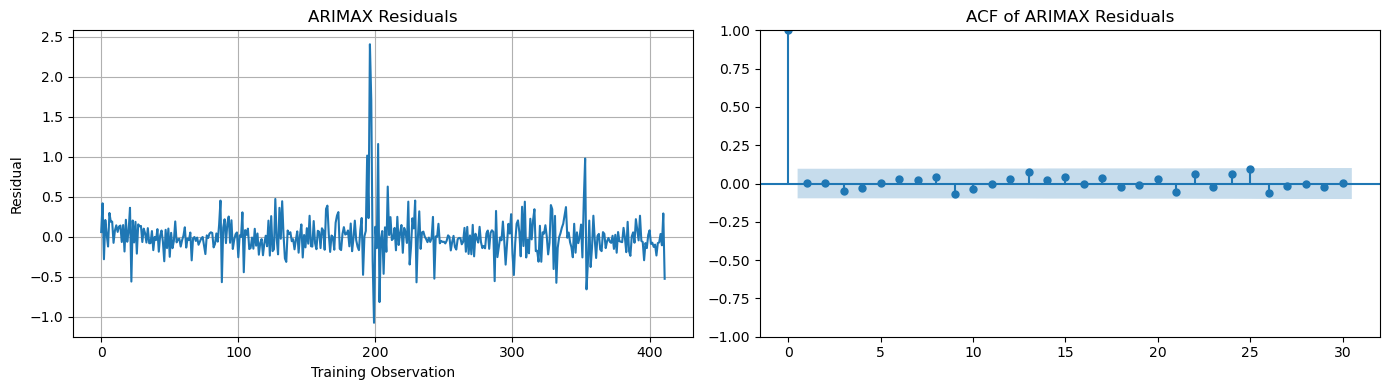

,lb_stat,lb_pvalue
10,5.246492,0.874116
20,10.574410,0.956522


In [20]:
# Fit final ARIMAX model and check residual diagnostics

arimax_model = SARIMAX(
    y_train,
    exog=X_train_arimax,
    order=best_arimax_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

arimax_result = arimax_model.fit(disp=False)

print(arimax_result.summary())

arimax_residuals = arimax_result.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(arimax_residuals)
axes[0].set_title("ARIMAX Residuals")
axes[0].set_xlabel("Training Observation")
axes[0].set_ylabel("Residual")
axes[0].grid(True)

plot_acf(arimax_residuals, lags=30, ax=axes[1])
axes[1].set_title("ACF of ARIMAX Residuals")

plt.tight_layout()
plt.show()

ljung_box_arimax = acorr_ljungbox(arimax_residuals, lags=[10, 20], return_df=True)

display(ljung_box_arimax)

## ARIMAX Residual Diagnostics Interpretation

The ARIMAX residual diagnostics suggest that the model captures most of the remaining serial dependence in the stress-change series. The residual ACF does not show strong remaining autocorrelation, and the Ljung-Box p-values at lags 10 and 20 are both well above 0.05. This means there is no strong evidence that the ARIMAX residuals contain systematic autocorrelation.

Several external predictors are statistically meaningful in the ARIMAX model. Current financial stress has a negative coefficient, which is consistent with mean reversion: when financial stress is already elevated, the next weekly change may be lower or negative. VIX changes and credit-spread changes have positive coefficients, meaning that increases in equity volatility and widening credit spreads are associated with higher future changes in financial stress. The 2-year Treasury-yield change is also significant in this specification, suggesting that short-rate movements contain additional information in the linear model.

The S&P 500 return and yield-curve change variables are not statistically significant in this ARIMAX specification. This does not mean they are useless for all models, but it suggests they are not strong linear predictors in this particular ARIMAX setup after controlling for the other variables.

The residual distribution remains non-normal and heavy-tailed, with evidence of heteroskedasticity. This is common in financial-stress data because large shocks are concentrated around crisis periods. These distributional issues should be acknowledged, but they do not prevent ARIMAX from being used as a forecasting benchmark because the main objective is out-of-sample predictive performance.

,model,rmse,mae,directional_accuracy,high_stress_rmse,high_stress_mae
0,ARIMAX,0.171063,0.123034,0.644231,0.185597,0.134553


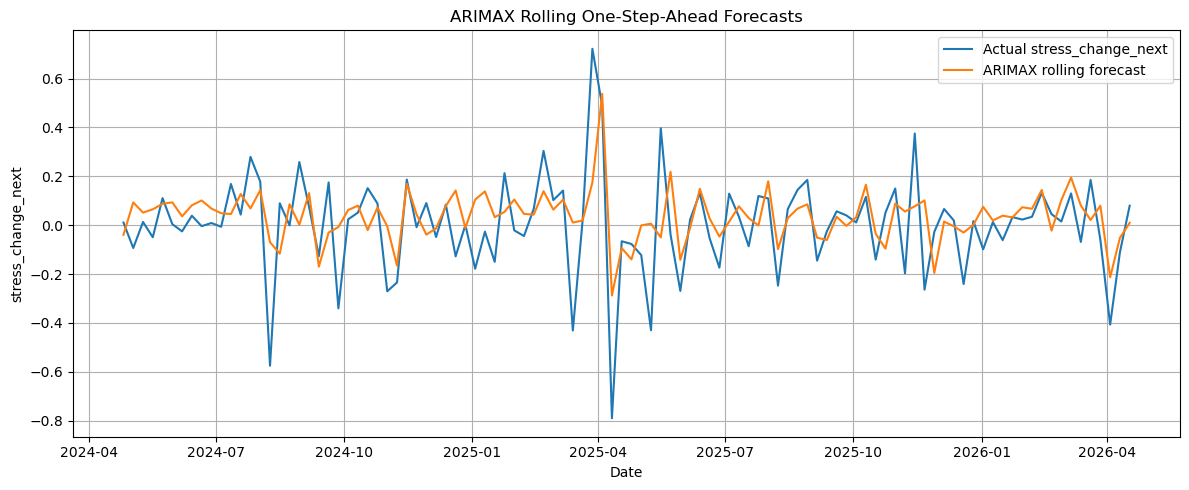

In [23]:
# Rolling one-step-ahead ARIMAX forecasts

arimax_history_y = list(y_train.values)
arimax_history_X = X_train_arimax.copy()

arimax_forecasts = []

for i in range(len(y_test)):
    current_exog = X_test_arimax.iloc[[i]]
    
    model = SARIMAX(
        arimax_history_y,
        exog=arimax_history_X,
        order=best_arimax_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False)
    
    forecast_series = result.forecast(
        steps=1,
        exog=current_exog
    )
    
    forecast = forecast_series.iloc[0]
    
    arimax_forecasts.append(forecast)
    
    arimax_history_y.append(y_test.values[i])
    arimax_history_X = pd.concat(
        [arimax_history_X, current_exog],
        axis=0
    )

arimax_forecasts = np.array(arimax_forecasts)

arimax_results = pd.DataFrame([
    evaluate_forecast(y_test.values, arimax_forecasts, "ARIMAX")
])

display(arimax_results)

plt.figure(figsize=(12, 5))

plt.plot(test_df["date"], y_test.values, label="Actual stress_change_next")
plt.plot(test_df["date"], arimax_forecasts, label="ARIMAX rolling forecast")

plt.title("ARIMAX Rolling One-Step-Ahead Forecasts")
plt.xlabel("Date")
plt.ylabel("stress_change_next")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ARIMAX Rolling Forecast Evaluation Interpretation

The ARIMAX rolling one-step-ahead forecast improves meaningfully over the baseline models and the univariate ARIMA benchmark. The rolling ARIMAX model produces a test RMSE of approximately 0.171 and a MAE of approximately 0.123, which are lower than the no-change baseline, the training-mean baseline, and the ARIMA model.

Directional accuracy increases to approximately 64.4%, meaning the ARIMAX model correctly predicts the direction of next-week financial stress changes in nearly two-thirds of the test observations. This is a stronger directional result than the ARIMA benchmark and suggests that external financial-market predictors improve the model’s ability to identify whether stress will rise or fall.

The largest improvement appears during high-stress-acceleration weeks. The rolling ARIMAX model reduces high-stress RMSE to approximately 0.186 and high-stress MAE to approximately 0.135. This is substantially better than the baseline and ARIMA high-stress errors. This directly supports the project’s main purpose: testing whether market-based indicators improve forecasts during weeks when financial stress is rising sharply.

The rolling forecast plot shows that ARIMAX tracks the direction and general movement of stress changes better than the simple baselines, although it still underestimates some of the largest stress shocks. This is expected because sudden financial-stress jumps are difficult to forecast using linear models.

Overall, the rolling ARIMAX results provide strong evidence that market-based indicators add useful forecasting information beyond the stress-change series’ own history. In this specification, current stress, VIX changes, credit-spread changes, short-rate changes, yield-curve changes, and equity returns improve short-horizon financial-stress-change forecasting relative to ARIMA.

# ARIMA vs ARIMAX Model Comparison

This section compares the univariate ARIMA benchmark against the ARIMAX model. ARIMA uses only the historical behavior of `stress_change_next`, while ARIMAX adds external market-based predictors such as current financial stress, VIX changes, credit-spread changes, S&P 500 returns, Treasury-yield changes, and yield-curve changes.

The purpose of this comparison is to test whether market-based financial indicators improve forecasting performance beyond the stress-change series' own history. This directly supports the project’s main question of whether volatility, credit, equity, and rate/yield-curve channels provide useful information for forecasting next-week changes in financial stress.

The comparison focuses on RMSE, MAE, directional accuracy, and high-stress-acceleration-week error. Lower RMSE and MAE indicate better forecast accuracy, while higher directional accuracy indicates better ability to predict whether financial stress rises or falls.

,model,rmse,mae,directional_accuracy,high_stress_rmse,high_stress_mae
0,ARIMA,0.195858,0.140546,0.557692,0.243304,0.198357
1,ARIMAX,0.171063,0.123034,0.644231,0.185597,0.134553


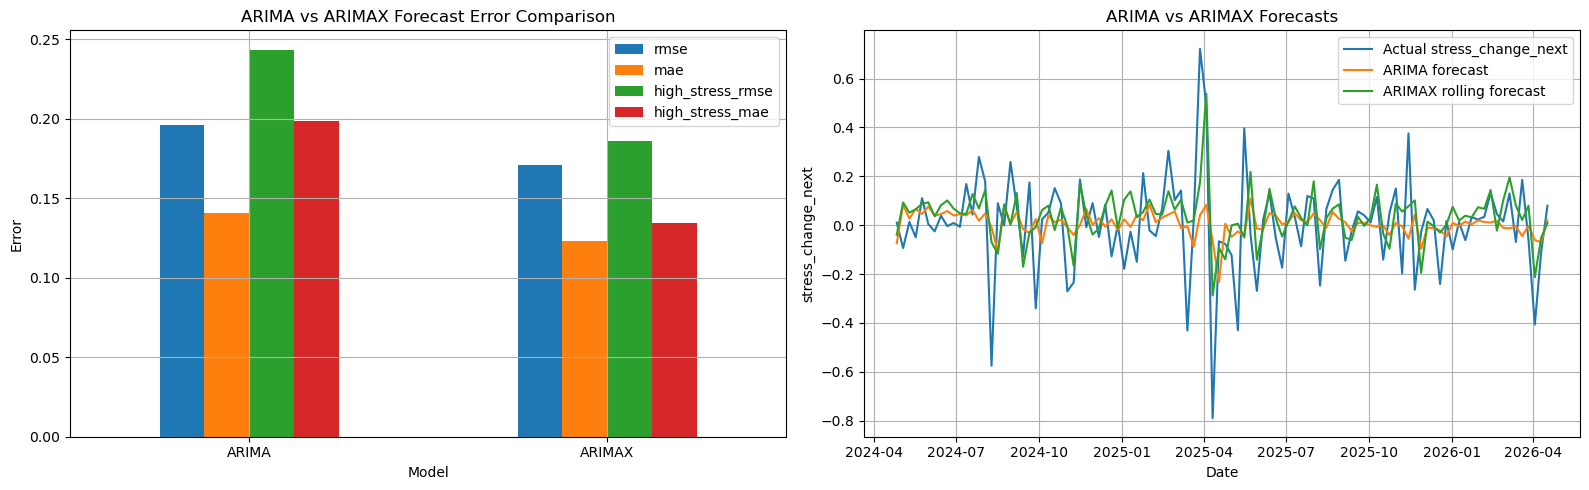

In [24]:
# Compare ARIMA and ARIMAX forecasts

arima_arimax_comparison = pd.concat(
    [arima_results, arimax_results],
    ignore_index=True
)

display(arima_arimax_comparison)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left plot: RMSE and MAE comparison
metric_plot = arima_arimax_comparison.set_index("model")[["rmse", "mae", "high_stress_rmse", "high_stress_mae"]]

metric_plot.plot(kind="bar", ax=axes[0])

axes[0].set_title("ARIMA vs ARIMAX Forecast Error Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Error")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(True)

# Right plot: forecast comparison
axes[1].plot(test_df["date"], y_test.values, label="Actual stress_change_next")
axes[1].plot(test_df["date"], arima_forecasts, label="ARIMA forecast")
axes[1].plot(test_df["date"], arimax_forecasts, label="ARIMAX rolling forecast")

axes[1].set_title("ARIMA vs ARIMAX Forecasts")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("stress_change_next")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## ARIMA vs ARIMAX Comparison Interpretation

The ARIMAX model outperforms the univariate ARIMA benchmark across every reported forecast metric. ARIMA produces a test RMSE of approximately 0.196 and a MAE of approximately 0.141, while ARIMAX reduces these values to approximately 0.171 and 0.123. This indicates that adding market-based predictors improves both squared-error performance and average absolute forecast accuracy.

Directional accuracy also improves from approximately 55.8% for ARIMA to approximately 64.4% for ARIMAX. This means ARIMAX is better at predicting whether next-week financial stress will rise or fall, not just at reducing the size of forecast errors.

The high-stress-acceleration results are especially important. ARIMA has a high-stress RMSE of approximately 0.243 and a high-stress MAE of approximately 0.198. ARIMAX reduces these to approximately 0.186 and 0.135. This is a substantial improvement and directly supports the project’s focus on stress-acceleration weeks, where forecasting performance matters most for risk monitoring.

The forecast comparison plot shows that ARIMAX tracks the actual stress-change series more closely than ARIMA across much of the test period. ARIMA tends to produce smaller, smoother forecasts near zero, while ARIMAX responds more strongly to market conditions. ARIMAX still misses some extreme stress movements, but it captures several directional shifts and stress-change movements better than the univariate model.

Overall, the ARIMA versus ARIMAX comparison provides clear evidence that external financial-market predictors improve short-horizon financial-stress-change forecasting. In this sample, current financial stress, volatility changes, credit-spread changes, equity returns, and rate/yield-curve changes add useful information beyond the stress-change series’ own history.

# VAR Model

The next model is VAR, or Vector Autoregression. Unlike ARIMA and ARIMAX, which model one target series directly, VAR models several related time series together as an endogenous system. This makes VAR useful for examining whether financial stress changes, volatility changes, credit-spread changes, equity returns, and rate/yield-curve changes contain lead-lag information about one another.

VAR is included because one of the project’s research questions asks whether financial stress indicators move together or whether one channel tends to lead changes in the official stress index. In this section, the VAR model is estimated using stationary variables, including `stress_change_next`, VIX changes, credit-spread changes, S&P 500 returns, Treasury-yield changes, and yield-curve changes.

This differs from ARIMAX. ARIMAX uses selected external predictors to forecast the stress-change target directly. VAR instead treats the variables as a joint multivariate time-series system and uses their lagged values to forecast future values.

The VAR workflow is:

- Select stationary variables for the VAR system.
- Choose the VAR lag order using training-set information criteria.
- Fit the final VAR model.
- Review the model summary.
- Check residual autocorrelation for the stress-change equation.
- Generate rolling one-step-ahead forecasts for `stress_change_next`.
- Compare VAR performance against the baselines, ARIMA, and ARIMAX.

In [25]:
# VAR feature setup

from statsmodels.tsa.api import VAR

var_cols = [
    "stress_change_next",
    "vix_change",
    "credit_spread_change",
    "sp500_return",
    "dgs2_change",
    "yield_curve_change"
]

var_train = train_df[var_cols].copy()
var_test = test_df[var_cols].copy()

print("VAR variables:")
print(var_cols)

print("\nTraining VAR shape:", var_train.shape)
print("Testing VAR shape:", var_test.shape)

display(var_train.head())
display(var_train.tail())

VAR variables:
['stress_change_next', 'vix_change', 'credit_spread_change', 'sp500_return', 'dgs2_change', 'yield_curve_change']

Training VAR shape: (412, 6)
Testing VAR shape: (104, 6)


,stress_change_next,vix_change,credit_spread_change,sp500_return,dgs2_change,yield_curve_change
0,0.0268,0.35,0.01,0.001034,-0.12,-0.02
1,0.4147,3.56,0.00,-0.001459,-0.05,-0.02
2,-0.3097,2.38,0.03,-0.011926,-0.03,0.01
3,0.3235,6.35,0.09,-0.016458,-0.06,0.01
4,-0.3756,-10.99,-0.12,0.031662,-0.05,-0.06


,stress_change_next,vix_change,credit_spread_change,sp500_return,dgs2_change,yield_curve_change
407,0.0071,-1.35,0.04,0.022624,-0.13,0.04
408,0.0919,-0.05,-0.03,0.003846,0.00,-0.02
409,0.0493,3.02,-0.01,-0.007548,0.14,0.05
410,0.3790,1.28,-0.04,-0.015673,0.15,-0.04
411,-0.4263,1.40,0.01,-0.030958,0.09,0.03


## VAR Feature Setup Interpretation

The VAR model uses six stationary financial change variables: next-week financial stress change, VIX change, credit-spread change, S&P 500 return, 2-year Treasury-yield change, and yield-curve change. These variables are used because VAR is designed for multivariate time-series systems where each variable may depend on its own past values and the past values of the other variables.

This setup differs from ARIMAX. ARIMAX treats the market indicators as external predictors for one target equation, while VAR treats the variables as part of a joint dynamic system. This makes VAR useful for evaluating whether stress, volatility, credit, equity, and rate/yield-curve channels move together through lagged relationships.

The selected VAR variables are therefore aligned with the project’s lead-lag research question: whether one financial channel tends to move before changes in the official stress index.

In [26]:
# VAR lag order selection

var_model_selection = VAR(var_train)

lag_order_results = var_model_selection.select_order(maxlags=8)

print(lag_order_results.summary())

selected_var_lag = lag_order_results.selected_orders["aic"]

if selected_var_lag is None or selected_var_lag == 0:
    selected_var_lag = 1

print("Selected VAR lag order:", selected_var_lag)

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -23.24      -23.18   8.043e-11      -23.22
1      -24.41     -23.99*   2.516e-11      -24.24
2      -24.61      -23.84   2.053e-11     -24.30*
3      -24.72      -23.59   1.842e-11      -24.27
4     -24.73*      -23.24  1.821e-11*      -24.14
5      -24.71      -22.87   1.858e-11      -23.98
6      -24.70      -22.50   1.885e-11      -23.83
7      -24.69      -22.13   1.903e-11      -23.68
8      -24.71      -21.80   1.872e-11      -23.56
-------------------------------------------------
Selected VAR lag order: 4


## VAR Lag Selection Interpretation

The VAR lag-selection results compare alternative lag lengths from 0 through 8 using AIC, BIC, FPE, and HQIC. The selected VAR lag order is 4, meaning the model uses the previous four weekly observations of each variable to forecast the current multivariate system.

Because the data are weekly, a VAR lag of 4 represents approximately one month of historical information. This suggests that the multivariate relationships among stress changes, volatility changes, credit-spread changes, equity returns, and rate/yield-curve changes may extend beyond a single week.

The selected VAR(4) specification is reasonable for this project because it allows the model to capture short-term lead-lag behavior across the main financial stress channels while avoiding an excessively long lag structure.

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 03, May, 2026
Time:                     15:24:39
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -23.1979
Nobs:                     408.000    HQIC:                  -24.0891
Log likelihood:           1709.65    FPE:                1.92850e-11
AIC:                     -24.6726    Det(Omega_mle):     1.34975e-11
--------------------------------------------------------------------
Results for equation stress_change_next
                             coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------------
const                          -0.014930         0.014609           -1.022           0.307
L1.stress_change_next           0.201212         0.053362            3.771           0.000
L1.vix_

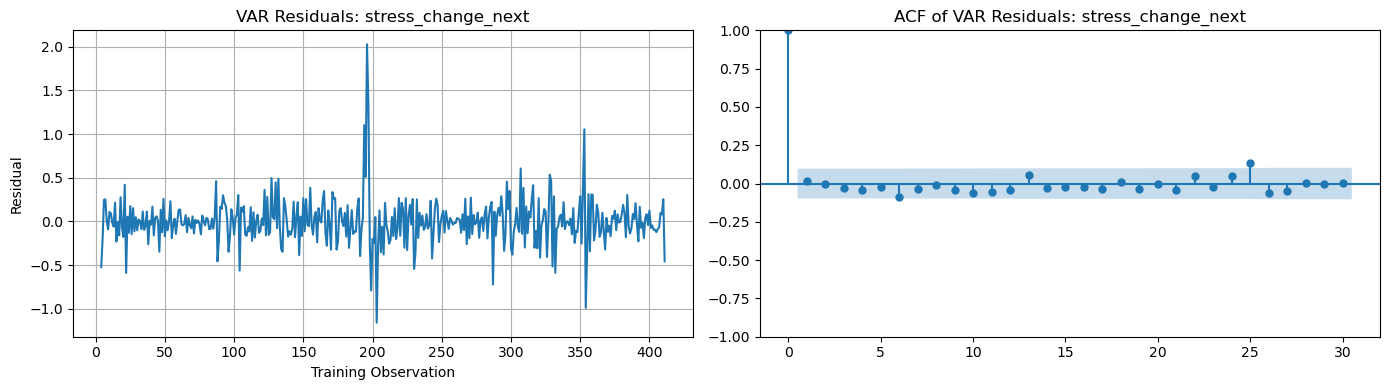

,lb_stat,lb_pvalue
10,7.407816,0.686465
20,12.484579,0.898389


In [32]:
# Fit final VAR model and check residual diagnostics

var_model = VAR(var_train)
var_result = var_model.fit(selected_var_lag)

print(var_result.summary())

var_residuals = var_result.resid["stress_change_next"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(var_residuals)
axes[0].set_title("VAR Residuals: stress_change_next")
axes[0].set_xlabel("Training Observation")
axes[0].set_ylabel("Residual")
axes[0].grid(True)

plot_acf(var_residuals, lags=30, ax=axes[1])
axes[1].set_title("ACF of VAR Residuals: stress_change_next")

plt.tight_layout()
plt.show()

ljung_box_var = acorr_ljungbox(var_residuals, lags=[10, 20], return_df=True)

display(ljung_box_var)

## VAR Coefficient Interpretation

The VAR summary reports one regression equation for each variable in the multivariate system. Each equation uses lagged values of all six variables to explain the current value of that equation's response variable. Because the main forecast target is `stress_change_next`, the most important equation is the first equation: the VAR equation for financial stress changes.

In the `stress_change_next` equation, the first lag of financial stress change is positive and statistically significant. The coefficient on `L1.stress_change_next` is approximately 0.201 with a p-value below 0.001. This means that last week’s stress change contains useful information for this week’s stress-change equation inside the VAR system.

VIX changes also show meaningful lead-lag information for stress changes. The coefficient on `L1.vix_change` is approximately 0.022 with a p-value of 0.002, and the coefficient on `L2.vix_change` is approximately 0.016 with a p-value of 0.032. The coefficient on `L3.vix_change` is also positive at approximately 0.019 with a p-value of 0.008. These results suggest that volatility changes over the prior one to three weeks contain useful information for financial stress changes.

Credit-spread changes show mixed but relevant evidence. The coefficient on `L1.credit_spread_change` is approximately -0.520 with a p-value of 0.035, while `L2.credit_spread_change` is approximately -0.490 with a p-value around 0.061. These signs should be interpreted cautiously because VAR coefficients are conditional on all other lagged variables in the system. They do not represent simple standalone correlations. Instead, they show that credit-spread movements contain conditional lead-lag information after accounting for stress, volatility, equity returns, and rate variables.

Equity returns also appear in the stress-change equation. The coefficient on `L1.sp500_return` is approximately 2.763 with a p-value of 0.007, and the coefficient on `L3.sp500_return` is approximately 2.104 with a p-value of 0.045. This indicates that lagged equity-market movement contributes to the VAR stress-change equation, though the positive sign should be interpreted as conditional on the full multivariate lag structure rather than as a simple market relationship.

Treasury variables are weaker in the short lags but still show some evidence. The 2-year Treasury-yield change is not significant at lags 1 through 3, but `L4.dgs2_change` is approximately 0.336 with a p-value of 0.023. This suggests that short-rate movements may contain slower-moving information over a roughly one-month lag. Yield-curve changes are not statistically significant in the `stress_change_next` equation, which suggests that the yield curve is weaker as a direct short-horizon predictor of next-week stress changes in this VAR specification.

The secondary equations confirm that the financial channels are dynamically related. For example, in the `vix_change` equation, `L1.stress_change_next` is approximately 8.617 with a p-value below 0.001, showing that stress changes are strongly related to later VIX changes. In the `sp500_return` equation, `L1.stress_change_next` is approximately -0.053 with a p-value below 0.001, showing that stress changes are also related to later equity-return behavior. In the `yield_curve_change` equation, `L1.stress_change_next` is approximately 0.042 with a p-value of 0.006, showing that the yield-curve system also reacts to lagged stress changes.

Overall, the VAR coefficient results support the existence of multivariate lead-lag relationships among stress, volatility, credit, equity, and rate/yield-curve variables. The strongest evidence for forecasting `stress_change_next` comes from lagged stress changes, lagged VIX changes, selected credit-spread changes, selected S&P 500 return lags, and the fourth lag of the 2-year Treasury-yield change. However, these coefficients are conditional VAR relationships and should not be interpreted as direct causal effects.

## VAR Residual Diagnostics Interpretation

The VAR residual diagnostics focus on the `stress_change_next` equation because that is the main forecasting target. The residual plot shows that the residuals generally fluctuate around zero, but there are several large shocks, especially around stress-event periods. This is expected in financial stress data because sudden jumps are difficult for linear models to fully anticipate.

The ACF of the VAR residuals shows little remaining serial correlation. Most autocorrelation values fall inside the confidence bands, which suggests that the VAR model captures most of the linear time-series dependence in the stress-change equation.

The Ljung-Box test supports this conclusion. At lag 10, the Ljung-Box p-value is approximately 0.686. At lag 20, the p-value is approximately 0.898. Both values are well above 0.05, so there is no strong evidence of remaining residual autocorrelation in the VAR stress-change equation.

The residual correlation matrix is not used to determine which variables forecast financial stress changes. It only shows contemporaneous relationships among the residual shocks after the VAR system is fitted. The largest residual relationship involving `stress_change_next` is with `vix_change`, at approximately 0.247, while its residual correlations with credit-spread changes, S&P 500 returns, Treasury-yield changes, and yield-curve changes are smaller. This suggests some remaining contemporaneous connection with volatility shocks, but it does not overturn the main residual result: the stress-change residuals do not show strong remaining autocorrelation.

Overall, the residual diagnostics are acceptable. The VAR model captures the main linear serial dependence in the stress-change equation, although the large residual shocks show that sudden financial-stress movements remain difficult to forecast.

,model,rmse,mae,directional_accuracy,high_stress_rmse,high_stress_mae
0,VAR,0.229818,0.151672,0.548077,0.302743,0.229771


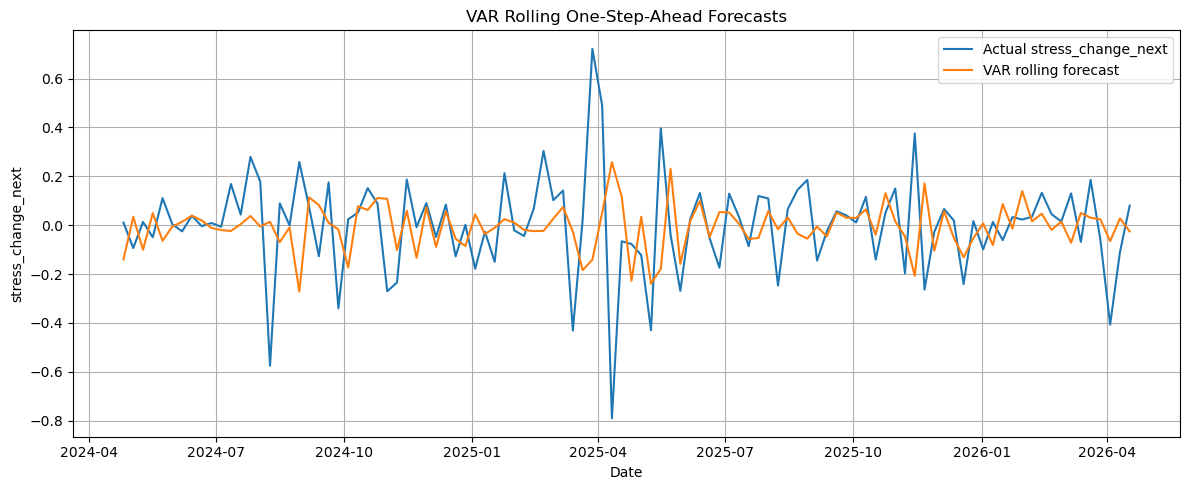

In [28]:
# Rolling one-step-ahead VAR forecasts

var_history = var_train.copy()
var_forecasts = []

for i in range(len(var_test)):
    model = VAR(var_history)
    result = model.fit(selected_var_lag)
    
    forecast_input = var_history.values[-selected_var_lag:]
    forecast = result.forecast(forecast_input, steps=1)
    
    stress_forecast = forecast[0, var_cols.index("stress_change_next")]
    var_forecasts.append(stress_forecast)
    
    var_history = pd.concat(
        [var_history, var_test.iloc[[i]]],
        axis=0
    )

var_forecasts = np.array(var_forecasts)

var_results = pd.DataFrame([
    evaluate_forecast(y_test.values, var_forecasts, "VAR")
])

display(var_results)

plt.figure(figsize=(12, 5))

plt.plot(test_df["date"], y_test.values, label="Actual stress_change_next")
plt.plot(test_df["date"], var_forecasts, label="VAR rolling forecast")

plt.title("VAR Rolling One-Step-Ahead Forecasts")
plt.xlabel("Date")
plt.ylabel("stress_change_next")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## VAR Rolling Forecast Evaluation Interpretation

The VAR rolling forecast does not outperform the ARIMA or ARIMAX models. VAR produces a test RMSE of approximately 0.229 and a MAE of approximately 0.152. These are worse than the ARIMA results and substantially worse than the rolling ARIMAX results.

Directional accuracy is approximately 54.8%, which is close to the ARIMA benchmark but below the ARIMAX model. This means VAR provides limited improvement in predicting whether financial stress will rise or fall.

The high-stress-acceleration results are weaker. VAR produces a high-stress RMSE of approximately 0.303 and a high-stress MAE of approximately 0.230, both of which are worse than ARIMA and ARIMAX. This suggests that the VAR model struggles during the weeks that matter most for stress-monitoring purposes.

The forecast plot shows that VAR captures some broad movements but does not track sharp stress changes well. The model tends to produce moderate forecasts and misses several large stress-change movements. This is a practical limitation of the VAR model in this project.

Overall, VAR is useful for examining multivariate lead-lag relationships among stress, volatility, credit, equity, and rate variables, but it is not the strongest forecasting model so far. The results suggest that the single-equation ARIMAX model uses the relevant market-channel information more effectively than the unrestricted VAR system.

## VAR Model Conclusion

The VAR model provides useful evidence that the financial stress channels are dynamically related. The coefficient results show meaningful lag relationships among stress changes, VIX changes, credit-spread changes, S&P 500 returns, and rate/yield-curve variables. This supports the use of VAR as a multivariate lead-lag diagnostic model.

However, VAR does not improve out-of-sample forecasting accuracy relative to ARIMA or ARIMAX. The VAR test RMSE is approximately 0.229 and the MAE is approximately 0.152, both of which are worse than the ARIMA and rolling ARIMAX results. The high-stress-acceleration metrics are also weaker, with high-stress RMSE of approximately 0.303 and high-stress MAE of approximately 0.230.

This means VAR is useful for showing that financial indicators interact over time, but it is not the strongest forecasting model in this project. The unrestricted multivariate system appears less effective than the more targeted ARIMAX model for predicting next-week changes in financial stress.

VAR supports the existence of multivariate financial-channel dynamics, but ARIMAX remains the stronger forecasting model so far.

# Random Forest Model

The next model is Random Forest, a nonlinear ensemble machine-learning model. Unlike ARIMA and ARIMAX, Random Forest does not impose a linear time-series structure. Instead, it uses many decision trees and averages their predictions to reduce variance and improve predictive stability.

Random Forest is included to test whether nonlinear combinations of financial indicators improve forecasts of next-week financial stress changes. This is important because stress acceleration may not behave linearly. For example, VIX changes, credit-spread changes, equity returns, and rate changes may become more informative when several risk channels deteriorate at the same time.

The model uses the same lagged financial feature set constructed earlier in the notebook. This preserves the time-series structure by giving the model information available at or before week `t` to forecast `stress_change_next` for week `t+1`. The chronological train/test split is retained to avoid look-ahead leakage.

The Random Forest workflow is:

- Use the existing lagged feature matrix from the modeling setup.
- Fit a Random Forest model on the training period.
- Apply moderate hyperparameter tuning using time-series cross-validation.
- Generate test-period forecasts.
- Compare RMSE, MAE, directional accuracy, and high-stress-week performance against the baselines, ARIMA, ARIMAX, and VAR.
- Check forecast-error autocorrelation using an error plot, ACF, and Ljung-Box test.
- Review feature importance to identify which financial channels contributed most to the model.

In [33]:
# Random Forest feature setup

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Use the shared feature set created earlier
X_train_rf = train_df[feature_cols].copy()
X_test_rf = test_df[feature_cols].copy()

print("Random Forest feature count:", len(feature_cols))
print("Training feature shape:", X_train_rf.shape)
print("Testing feature shape:", X_test_rf.shape)

print("\nRandom Forest features:")
print(feature_cols)

display(X_train_rf.head())
display(X_train_rf.tail())

Random Forest feature count: 23
Training feature shape: (412, 23)
Testing feature shape: (104, 23)

Random Forest features:
['stress', 'stress_lag1', 'stress_lag4', 'vix_lag1', 'vix_lag4', 'credit_spread_lag1', 'credit_spread_lag4', 'dgs2_lag1', 'dgs2_lag4', 'dgs10_lag1', 'dgs10_lag4', 'yield_curve_lag1', 'yield_curve_lag4', 'sp500_return_lag1', 'sp500_return_lag4', 'sp500_return_4w_mean', 'sp500_abs_return_4w_mean', 'vix_change', 'credit_spread_change', 'dgs2_change', 'dgs10_change', 'yield_curve_change', 'sp500_return']


,stress,stress_lag1,stress_lag4,vix_lag1,vix_lag4,credit_spread_lag1,credit_spread_lag4,dgs2_lag1,dgs2_lag4,dgs10_lag1,...,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean,vix_change,credit_spread_change,dgs2_change,dgs10_change,yield_curve_change,sp500_return
0,0.1254,-0.0029,0.2686,13.12,14.72,2.85,2.87,0.90,0.74,1.85,...,0.022519,-0.011738,0.002109,0.010544,0.35,0.01,-0.12,-0.14,-0.02,0.001034
1,0.1522,0.1254,0.1787,13.47,15.04,2.86,2.90,0.78,0.76,1.71,...,0.001034,-0.005132,0.005302,0.007868,3.56,0.00,-0.05,-0.07,-0.02,-0.001459
2,0.5669,0.1522,0.0768,17.03,15.20,2.86,2.86,0.73,0.89,1.64,...,-0.001459,0.002786,0.006220,0.006949,2.38,0.03,-0.03,-0.02,0.01,-0.011926
3,0.2572,0.5669,-0.0029,19.41,13.12,2.89,2.85,0.70,0.90,1.62,...,-0.011926,0.022519,0.002542,0.009235,6.35,0.09,-0.06,-0.05,0.01,-0.016458
4,0.5807,0.2572,0.1254,25.76,13.47,2.98,2.86,0.64,0.78,1.57,...,-0.016458,0.001034,-0.007202,0.007719,-10.99,-0.12,-0.05,-0.11,-0.06,0.031662


,stress,stress_lag1,stress_lag4,vix_lag1,vix_lag4,credit_spread_lag1,credit_spread_lag4,dgs2_lag1,dgs2_lag4,dgs10_lag1,...,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean,vix_change,credit_spread_change,dgs2_change,dgs10_change,yield_curve_change,sp500_return
407,-0.9419,-0.9231,-0.6724,14.41,13.75,1.49,1.49,4.72,4.67,4.31,...,-0.001289,0.022514,0.007015,0.008964,-1.35,0.04,-0.13,-0.09,0.04,0.022624
408,-0.9348,-0.9419,-0.7918,13.06,13.11,1.53,1.57,4.59,4.54,4.22,...,0.022624,0.009443,0.007042,0.008991,-0.05,-0.03,0.00,-0.02,-0.02,0.003846
409,-0.8429,-0.9348,-0.7933,13.01,14.74,1.50,1.59,4.59,4.48,4.20,...,0.003846,-0.002610,0.005643,0.007592,3.02,-0.01,0.14,0.19,0.05,-0.007548
410,-0.7936,-0.8429,-0.9231,16.03,14.41,1.49,1.49,4.73,4.72,4.39,...,-0.007548,-0.001289,0.004408,0.008827,1.28,-0.04,0.15,0.11,-0.04,-0.015673
411,-0.4146,-0.7936,-0.9419,17.31,13.06,1.45,1.53,4.88,4.59,4.50,...,-0.015673,0.022624,0.000812,0.012423,1.40,0.01,0.09,0.12,0.03,-0.030958


## Random Forest Feature Setup Interpretation

The Random Forest model uses the full shared feature set created during the modeling setup. This includes current financial stress, lagged stress, lagged market indicators, current weekly changes, and S&P 500 return features.

The feature matrix contains 23 predictors across 412 training observations and 104 testing observations. These predictors are constructed using information available at or before week `t` to forecast `stress_change_next`, which measures the next-week change in financial stress.

Unlike ARIMAX, Random Forest can handle a larger feature set because it is not estimating one linear coefficient for each variable in the same way. This allows the model to test whether nonlinear interactions among volatility, credit spreads, equity returns, rates, and lagged stress improve forecasting performance.

In [34]:
# Random Forest model fitting with moderate time-series tuning

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [3, 5, 10],
    "max_features": ["sqrt", 0.5]
}

tscv = TimeSeriesSplit(n_splits=5)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1
)

rf_grid.fit(X_train_rf, y_train)

best_rf_model = rf_grid.best_estimator_

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest cross-validation MAE:")
print(-rf_grid.best_score_)

Best Random Forest parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 500}

Best cross-validation MAE:
0.18221247282486175


## Random Forest Tuning Interpretation

The Random Forest model was tuned using time-series cross-validation rather than random cross-validation. This preserves the temporal ordering of the data and avoids training on future observations when validating earlier periods.

The selected Random Forest parameters are `max_depth = 5`, `max_features = sqrt`, `min_samples_leaf = 10`, and `n_estimators = 500`. This is a relatively controlled Random Forest specification. The limited tree depth and larger minimum leaf size reduce the risk of overfitting, while the larger number of trees improves prediction stability.

The best cross-validation MAE is approximately 0.182. This value is based on validation folds inside the training period and should not be interpreted as the final test performance. The final evaluation still comes from the chronological holdout test set.

,model,rmse,mae,directional_accuracy,high_stress_rmse,high_stress_mae
0,Random Forest,0.182051,0.120875,0.701923,0.224117,0.173626


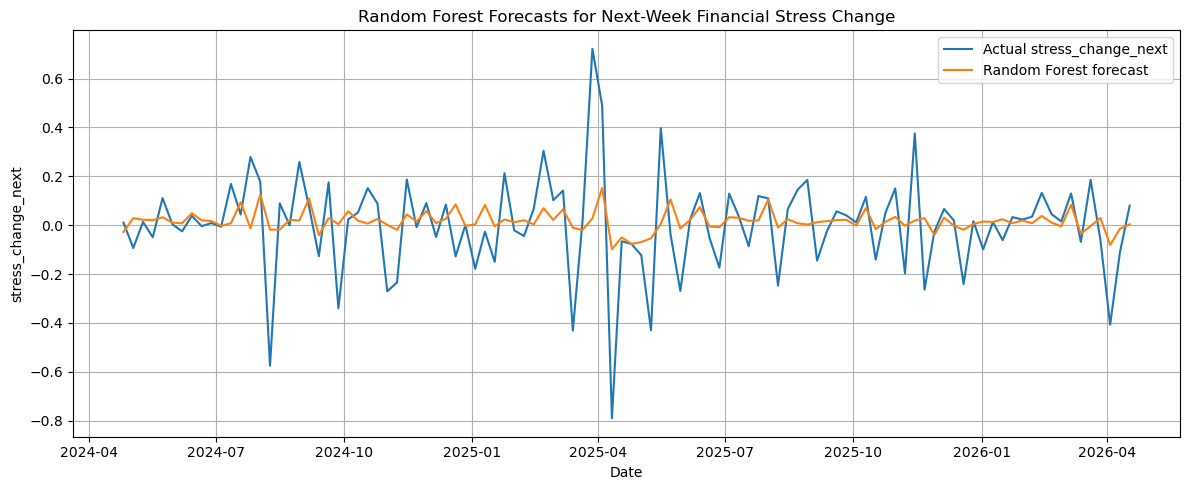

In [35]:
# Random Forest test-period forecast evaluation

rf_forecasts = best_rf_model.predict(X_test_rf)

rf_results = pd.DataFrame([
    evaluate_forecast(y_test.values, rf_forecasts, "Random Forest")
])

display(rf_results)

plt.figure(figsize=(12, 5))

plt.plot(test_df["date"], y_test.values, label="Actual stress_change_next")
plt.plot(test_df["date"], rf_forecasts, label="Random Forest forecast")

plt.title("Random Forest Forecasts for Next-Week Financial Stress Change")
plt.xlabel("Date")
plt.ylabel("stress_change_next")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Random Forest Forecast Evaluation Interpretation

The Random Forest model produces a test RMSE of approximately 0.182 and a MAE of approximately 0.121. This improves over the baseline models, ARIMA, and VAR on overall forecast error. Compared with ARIMAX, Random Forest has a higher RMSE but a slightly lower MAE.

This distinction matters. The lower MAE suggests that Random Forest performs well on the average absolute forecast error, but the higher RMSE suggests that it still misses some larger stress-change movements. Since RMSE penalizes large errors more heavily, this indicates that Random Forest may underperform ARIMAX during larger stress shocks.

Directional accuracy is approximately 70.2%, which is the strongest directional result so far. This means Random Forest is better at predicting whether financial stress will rise or fall than the previous models.

During high-stress-acceleration weeks, Random Forest produces a high-stress RMSE of approximately 0.224 and a high-stress MAE of approximately 0.174. These values improve over ARIMA and VAR, but they are weaker than the rolling ARIMAX high-stress results. This suggests that Random Forest helps with direction and average error, but ARIMAX remains stronger during sharp stress-acceleration weeks.

Overall, Random Forest earns its place in the model comparison because it improves directional accuracy and average absolute error. However, it does not clearly dominate ARIMAX because its high-stress-week performance is weaker.

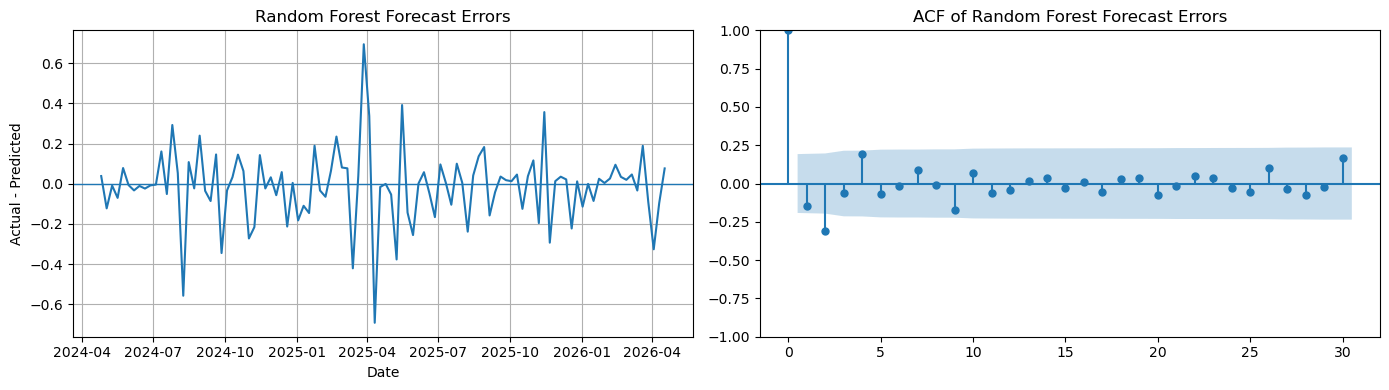

,lb_stat,lb_pvalue
10,22.794169,0.011532
20,25.119246,0.196907


In [36]:
# Random Forest forecast-error diagnostics

rf_errors = y_test.values - rf_forecasts

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_df["date"], rf_errors)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("Random Forest Forecast Errors")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Actual - Predicted")
axes[0].grid(True)

plot_acf(rf_errors, lags=30, ax=axes[1])
axes[1].set_title("ACF of Random Forest Forecast Errors")

plt.tight_layout()
plt.show()

ljung_box_rf = acorr_ljungbox(rf_errors, lags=[10, 20], return_df=True)

display(ljung_box_rf)

## Random Forest Forecast-Error Diagnostics Interpretation

The Random Forest forecast-error plot shows that most errors fluctuate around zero, but several large errors remain during stress-event periods. This is consistent with the forecast plot, where the model underestimates some of the largest positive and negative stress changes.

The ACF of the forecast errors shows some remaining short-run autocorrelation. The Ljung-Box test at lag 10 has a p-value of approximately 0.012, which is below 0.05. This suggests that the Random Forest forecast errors retain some short-horizon serial structure. At lag 20, the p-value rises to approximately 0.197, meaning the evidence of remaining autocorrelation is weaker over longer lag horizons.

For Random Forest, this is not the same kind of assumption violation as it would be for a fitted ARIMA residual process. Instead, it indicates that the model may not fully capture short-term time-series dependence in the test-period forecast errors.

Overall, the Random Forest diagnostics are acceptable for comparison, but the remaining short-run error autocorrelation should be acknowledged as a limitation.

,feature,importance
0,vix_change,0.097495
1,stress,0.090949
2,stress_lag1,0.074165
3,sp500_return,0.072282
4,vix_lag4,0.065529
5,vix_lag1,0.063329
6,credit_spread_lag1,0.057811
7,sp500_return_4w_mean,0.052835
8,stress_lag4,0.049745
9,sp500_abs_return_4w_mean,0.047970


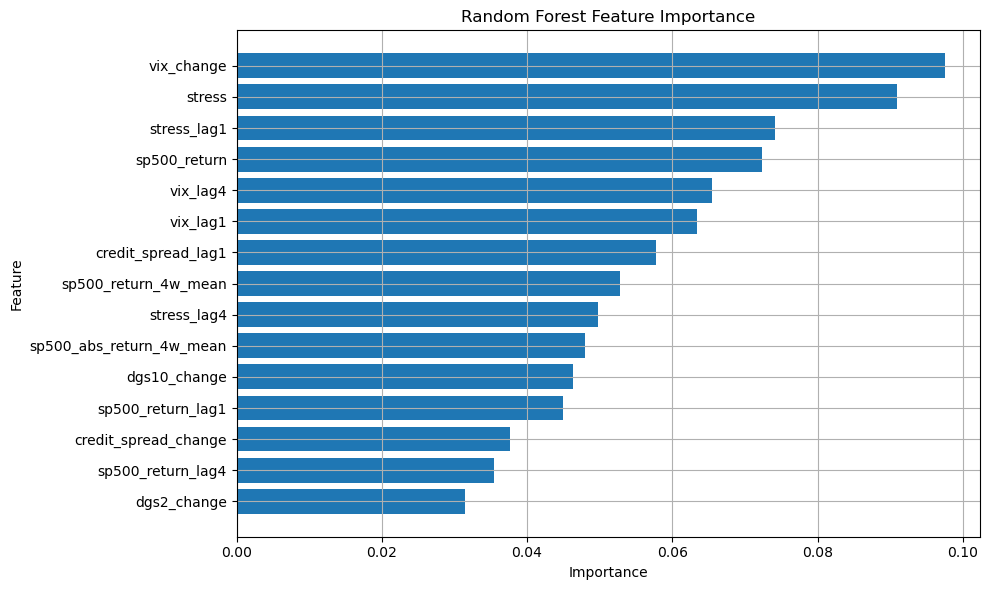

In [37]:
# Random Forest feature importance

rf_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(rf_feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_feature_importance["feature"].head(15)[::-1],
    rf_feature_importance["importance"].head(15)[::-1]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()

## Random Forest Feature Importance Interpretation

The Random Forest feature-importance results show that volatility and current stress conditions are the most important predictors in the model. The top feature is `vix_change`, with an importance of approximately 0.0975. This suggests that recent changes in equity-market volatility are highly informative for forecasting next-week changes in financial stress.

Current `stress` is the second most important feature, with an importance of approximately 0.0909. This supports the earlier modeling logic that current stress helps capture mean-reversion or continuation behavior in future stress changes. The feature `stress_lag1` is also highly ranked, with an importance of approximately 0.0742, showing that recent stress history remains important.

Equity-market variables also contribute meaningfully. `sp500_return` has an importance of approximately 0.0723, while `sp500_return_4w_mean` and `sp500_abs_return_4w_mean` also appear in the top features. This suggests that both current equity performance and recent equity-market movement help the nonlinear model forecast stress changes.

VIX lag variables are also important. Both `vix_lag4` and `vix_lag1` rank highly, indicating that volatility conditions over both short and roughly one-month horizons contribute to the model.

Credit-spread variables are present but less dominant than VIX and stress variables. `credit_spread_lag1` ranks within the top features, suggesting that recent credit-market stress contains useful information, but it is not the strongest Random Forest channel.

Treasury-yield and yield-curve variables generally rank lower. This suggests that rate and yield-curve features provide some information, but they are weaker predictors than volatility, stress persistence, equity returns, and credit spreads in this Random Forest specification.

Overall, the feature-importance results support a clear channel ranking: volatility changes and current stress conditions matter most, followed by equity-market behavior, lagged volatility, lagged stress, and credit spreads. Rate and yield-curve variables contribute less strongly in the Random Forest model.

## Random Forest Model Conclusion

The Random Forest model improves the overall forecast comparison by testing whether nonlinear combinations of financial indicators help predict next-week changes in financial stress. The model performs well on MAE and directional accuracy, with directional accuracy rising to approximately 70.2%, the strongest result so far.

However, Random Forest does not fully dominate ARIMAX. Its RMSE is higher than ARIMAX, and its high-stress-acceleration performance is weaker than ARIMAX. This suggests that Random Forest is useful for identifying the direction of stress changes and reducing average absolute errors, but it is less effective than ARIMAX during larger stress shocks.

The feature-importance results are still valuable because they provide a clear channel ranking. VIX changes, current stress, lagged stress, S&P 500 returns, lagged VIX, and credit-spread variables are the strongest contributors. This supports the project’s broader conclusion that volatility, stress persistence, equity-market movement, and credit conditions are the most informative channels for short-horizon financial-stress forecasting.

Random Forest is therefore a useful nonlinear benchmark, but ARIMAX remains the stronger model for high-stress-acceleration weeks so far.

# XGBoost Model

The next model is XGBoost, a boosted tree-based machine-learning model. Like Random Forest, XGBoost can capture nonlinear relationships among financial indicators, but it builds trees sequentially so that each new tree attempts to correct errors from the prior trees.

XGBoost is included to test whether a stronger nonlinear model improves forecasts of next-week financial stress changes beyond Random Forest, ARIMAX, VAR, and ARIMA. This is especially relevant for high-stress-acceleration weeks, where the model may need to identify nonlinear combinations of volatility changes, credit-spread changes, equity returns, lagged stress, and rate/yield-curve movements.

The model uses the same shared feature set as Random Forest. This keeps the comparison fair because both nonlinear models receive the same information. Any difference in performance should therefore reflect model structure rather than different predictor availability.

The XGBoost workflow is:

- Use the same lagged feature matrix as Random Forest.
- Fit XGBoost using moderate time-series cross-validation.
- Generate test-period forecasts.
- Compare RMSE, MAE, directional accuracy, and high-stress-week performance against all previous models.
- Check forecast-error autocorrelation using an error plot, ACF, and Ljung-Box test.
- Review feature importance to identify which financial channels contributed most to the boosted model.

In [38]:
# XGBoost feature setup

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError:
    raise ModuleNotFoundError("XGBoost is not installed. Run `%pip install xgboost` in a notebook cell, then rerun this section.")

X_train_xgb = train_df[feature_cols].copy()
X_test_xgb = test_df[feature_cols].copy()

print("XGBoost feature count:", len(feature_cols))
print("Training feature shape:", X_train_xgb.shape)
print("Testing feature shape:", X_test_xgb.shape)

print("\nXGBoost features:")
print(feature_cols)

display(X_train_xgb.head())
display(X_train_xgb.tail())

XGBoost feature count: 23
Training feature shape: (412, 23)
Testing feature shape: (104, 23)

XGBoost features:
['stress', 'stress_lag1', 'stress_lag4', 'vix_lag1', 'vix_lag4', 'credit_spread_lag1', 'credit_spread_lag4', 'dgs2_lag1', 'dgs2_lag4', 'dgs10_lag1', 'dgs10_lag4', 'yield_curve_lag1', 'yield_curve_lag4', 'sp500_return_lag1', 'sp500_return_lag4', 'sp500_return_4w_mean', 'sp500_abs_return_4w_mean', 'vix_change', 'credit_spread_change', 'dgs2_change', 'dgs10_change', 'yield_curve_change', 'sp500_return']


,stress,stress_lag1,stress_lag4,vix_lag1,vix_lag4,credit_spread_lag1,credit_spread_lag4,dgs2_lag1,dgs2_lag4,dgs10_lag1,...,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean,vix_change,credit_spread_change,dgs2_change,dgs10_change,yield_curve_change,sp500_return
0,0.1254,-0.0029,0.2686,13.12,14.72,2.85,2.87,0.90,0.74,1.85,...,0.022519,-0.011738,0.002109,0.010544,0.35,0.01,-0.12,-0.14,-0.02,0.001034
1,0.1522,0.1254,0.1787,13.47,15.04,2.86,2.90,0.78,0.76,1.71,...,0.001034,-0.005132,0.005302,0.007868,3.56,0.00,-0.05,-0.07,-0.02,-0.001459
2,0.5669,0.1522,0.0768,17.03,15.20,2.86,2.86,0.73,0.89,1.64,...,-0.001459,0.002786,0.006220,0.006949,2.38,0.03,-0.03,-0.02,0.01,-0.011926
3,0.2572,0.5669,-0.0029,19.41,13.12,2.89,2.85,0.70,0.90,1.62,...,-0.011926,0.022519,0.002542,0.009235,6.35,0.09,-0.06,-0.05,0.01,-0.016458
4,0.5807,0.2572,0.1254,25.76,13.47,2.98,2.86,0.64,0.78,1.57,...,-0.016458,0.001034,-0.007202,0.007719,-10.99,-0.12,-0.05,-0.11,-0.06,0.031662


,stress,stress_lag1,stress_lag4,vix_lag1,vix_lag4,credit_spread_lag1,credit_spread_lag4,dgs2_lag1,dgs2_lag4,dgs10_lag1,...,sp500_return_lag1,sp500_return_lag4,sp500_return_4w_mean,sp500_abs_return_4w_mean,vix_change,credit_spread_change,dgs2_change,dgs10_change,yield_curve_change,sp500_return
407,-0.9419,-0.9231,-0.6724,14.41,13.75,1.49,1.49,4.72,4.67,4.31,...,-0.001289,0.022514,0.007015,0.008964,-1.35,0.04,-0.13,-0.09,0.04,0.022624
408,-0.9348,-0.9419,-0.7918,13.06,13.11,1.53,1.57,4.59,4.54,4.22,...,0.022624,0.009443,0.007042,0.008991,-0.05,-0.03,0.00,-0.02,-0.02,0.003846
409,-0.8429,-0.9348,-0.7933,13.01,14.74,1.50,1.59,4.59,4.48,4.20,...,0.003846,-0.002610,0.005643,0.007592,3.02,-0.01,0.14,0.19,0.05,-0.007548
410,-0.7936,-0.8429,-0.9231,16.03,14.41,1.49,1.49,4.73,4.72,4.39,...,-0.007548,-0.001289,0.004408,0.008827,1.28,-0.04,0.15,0.11,-0.04,-0.015673
411,-0.4146,-0.7936,-0.9419,17.31,13.06,1.45,1.53,4.88,4.59,4.50,...,-0.015673,0.022624,0.000812,0.012423,1.40,0.01,0.09,0.12,0.03,-0.030958


## XGBoost Feature Setup Interpretation

The XGBoost model uses the same 23-predictor feature set as Random Forest. This includes current financial stress, lagged stress, lagged market indicators, weekly market changes, and equity-return features.

Using the same feature set keeps the nonlinear model comparison fair. Random Forest and XGBoost are tested on the same information, so any difference in performance reflects model structure rather than differences in predictor selection.

The predictors are valid for forecasting because they use information available at or before week `t` to forecast `stress_change_next` for week `t+1`. Therefore, this setup avoids look-ahead leakage while allowing the model to learn nonlinear relationships among volatility, credit, equity, stress, and rate/yield-curve variables.

In [39]:
# XGBoost model fitting with time-series tuning

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    importance_type="gain"
)

xgb_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [2, 3],
    "learning_rate": [0.03, 0.05, 0.10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [3, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1
)

xgb_grid.fit(X_train_xgb, y_train)

best_xgb_model = xgb_grid.best_estimator_

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)

print("\nBest cross-validation MAE:")
print(-xgb_grid.best_score_)

Best XGBoost parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.8}

Best cross-validation MAE:
0.1859899423679375


## XGBoost Tuning Interpretation

The XGBoost model was tuned using time-series cross-validation rather than random cross-validation. This preserves the chronological order of the data and avoids validating on earlier periods using information from later periods.

The selected parameters are `colsample_bytree = 0.8`, `learning_rate = 0.03`, `max_depth = 2`, `min_child_weight = 3`, `n_estimators = 100`, and `subsample = 0.8`. This is a relatively conservative boosted-tree specification. The shallow tree depth limits overfitting, while the low learning rate makes the boosting process more gradual.

The best cross-validation MAE is approximately 0.186. This value is based only on validation folds inside the training period and is not the final model performance. The final comparison is based on the chronological test-period results.

,model,rmse,mae,directional_accuracy,high_stress_rmse,high_stress_mae
0,XGBoost,0.188292,0.126263,0.644231,0.218085,0.168368


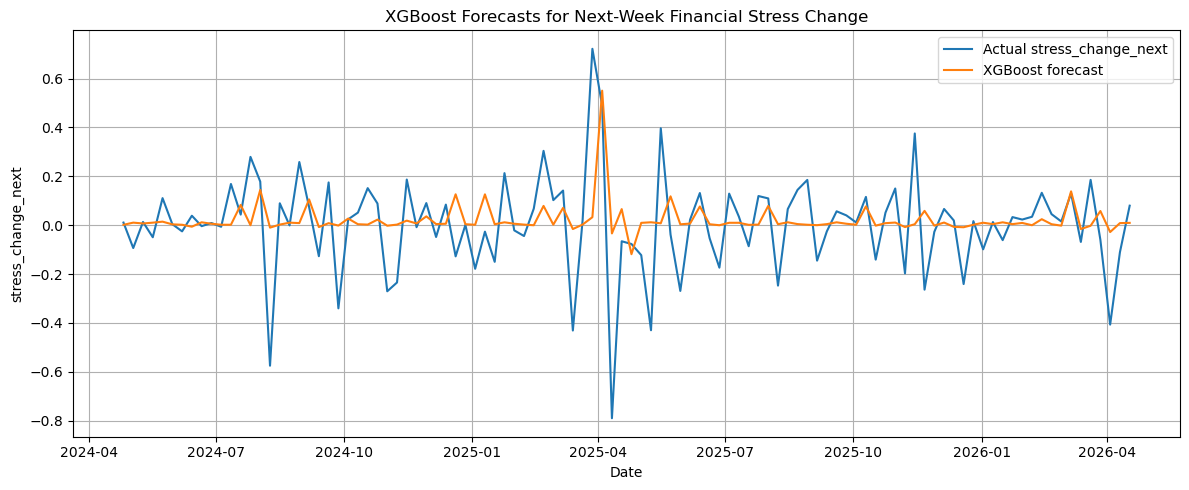

In [40]:
# XGBoost test-period forecast evaluation

xgb_forecasts = best_xgb_model.predict(X_test_xgb)

xgb_results = pd.DataFrame([
    evaluate_forecast(y_test.values, xgb_forecasts, "XGBoost")
])

display(xgb_results)

plt.figure(figsize=(12, 5))

plt.plot(test_df["date"], y_test.values, label="Actual stress_change_next")
plt.plot(test_df["date"], xgb_forecasts, label="XGBoost forecast")

plt.title("XGBoost Forecasts for Next-Week Financial Stress Change")
plt.xlabel("Date")
plt.ylabel("stress_change_next")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## XGBoost Forecast Evaluation Interpretation

The XGBoost model produces a test RMSE of approximately 0.188 and a MAE of approximately 0.126. This improves over the baseline models, ARIMA, and VAR, but it does not outperform the rolling ARIMAX model. Compared with Random Forest, XGBoost has a slightly higher RMSE and MAE, meaning Random Forest performs better on average forecast error.

Directional accuracy is approximately 64.4%, matching the rolling ARIMAX model but falling below Random Forest. This means XGBoost identifies the correct direction of next-week financial stress changes in roughly two-thirds of the test observations.

During high-stress-acceleration weeks, XGBoost produces a high-stress RMSE of approximately 0.218 and a high-stress MAE of approximately 0.168. These values are better than Random Forest’s high-stress-week metrics, but still weaker than ARIMAX. This suggests that XGBoost improves somewhat during sharper stress-change weeks relative to Random Forest, but it does not surpass the linear ARIMAX benchmark.

The forecast plot shows that XGBoost produces relatively conservative forecasts. It captures some movements in the stress-change series, but it still underestimates several large positive and negative stress shocks. Overall, XGBoost adds value as a nonlinear benchmark, but it is not the strongest model in this project.

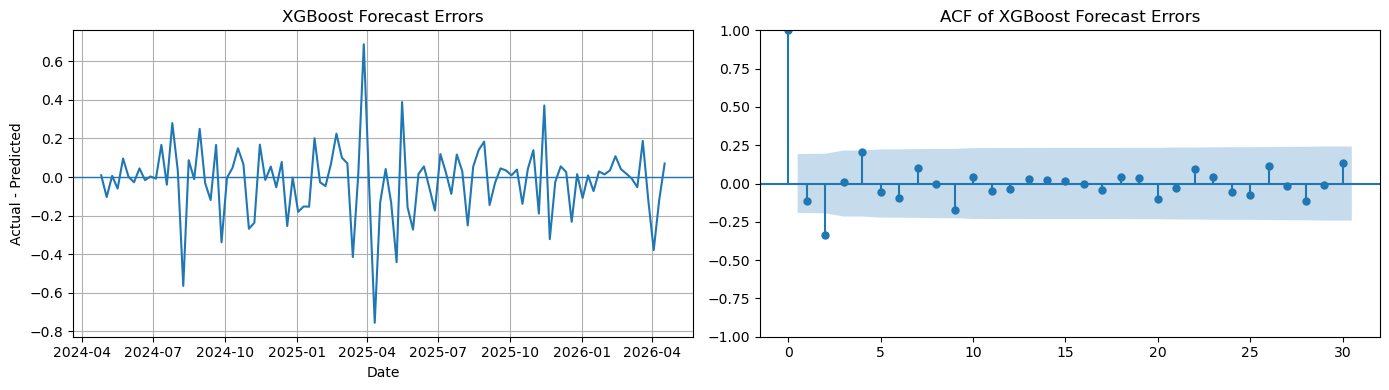

,lb_stat,lb_pvalue
10,24.850070,0.005637
20,27.528271,0.121045


In [41]:
# XGBoost forecast-error diagnostics

xgb_errors = y_test.values - xgb_forecasts

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_df["date"], xgb_errors)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("XGBoost Forecast Errors")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Actual - Predicted")
axes[0].grid(True)

plot_acf(xgb_errors, lags=30, ax=axes[1])
axes[1].set_title("ACF of XGBoost Forecast Errors")

plt.tight_layout()
plt.show()

ljung_box_xgb = acorr_ljungbox(xgb_errors, lags=[10, 20], return_df=True)

display(ljung_box_xgb)

## XGBoost Forecast-Error Diagnostics Interpretation

The XGBoost forecast-error plot shows that most forecast errors fluctuate around zero, but several large errors remain during stress-event periods. This indicates that the model still struggles with sudden financial-stress jumps.

The forecast-error ACF shows evidence of remaining short-run dependence. The Ljung-Box p-value at lag 10 is approximately 0.0056, which is below 0.05. This suggests that the XGBoost forecast errors contain remaining autocorrelation over shorter horizons.

At lag 20, the Ljung-Box p-value rises to approximately 0.121, which is above 0.05. This means the evidence of remaining autocorrelation is weaker over longer lag horizons.

For XGBoost, this is not the same type of formal assumption failure as it would be for ARIMA residuals. However, it is a useful diagnostic warning. The model may not be fully capturing short-run temporal structure in the stress-change process.

Overall, the forecast-error diagnostics are acceptable for model comparison, but the remaining short-run autocorrelation should be noted as a limitation.

,feature,importance
0,credit_spread_lag4,0.097937
1,credit_spread_change,0.077755
2,credit_spread_lag1,0.072742
3,stress_lag4,0.068212
4,vix_lag1,0.060404
5,stress_lag1,0.059148
6,vix_lag4,0.058184
7,stress,0.057015
8,yield_curve_lag4,0.055839
9,sp500_return,0.051053


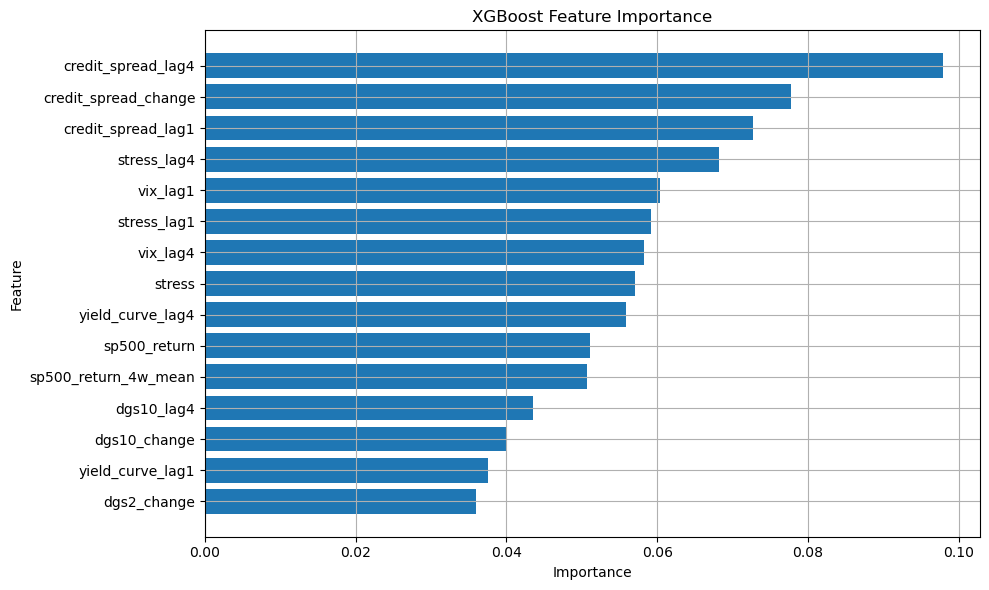

In [42]:
# XGBoost feature importance

xgb_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(xgb_feature_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    xgb_feature_importance["feature"].head(15)[::-1],
    xgb_feature_importance["importance"].head(15)[::-1]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.tight_layout()
plt.show()

## XGBoost Feature Importance Interpretation

The XGBoost feature-importance results show that credit-spread variables are the most influential predictors in the boosted model. The top feature is `credit_spread_lag4`, with an importance of approximately 0.097. This suggests that credit-market stress from roughly one month earlier contains important information for forecasting next-week changes in financial stress.

The next most important features are `credit_spread_change`, with importance around 0.078, and `credit_spread_lag1`, with importance around 0.073. This indicates that XGBoost relies heavily on both recent credit-spread changes and lagged credit-spread levels. Compared with Random Forest, XGBoost places more emphasis on the credit channel.

Lagged stress variables are also important. `stress_lag4` has an importance of approximately 0.068, and `stress_lag1` has an importance of approximately 0.059. This supports the idea that financial stress has both short-term and approximately one-month lag structure.

Volatility variables remain relevant. `vix_lag1` and `vix_lag4` both appear among the top predictors, showing that recent and one-month-lagged volatility conditions contribute to the boosted model. However, `vix_change` ranks lower than it did in Random Forest, which suggests that XGBoost is relying more heavily on credit spreads and lagged levels than immediate VIX changes.

Equity variables also contribute. `sp500_return` and `sp500_return_4w_mean` appear in the top set of features, suggesting that current equity-market performance and recent equity-return trends help explain stress-change forecasts.

Rate and yield-curve variables are mixed. `yield_curve_lag4`, `dgs10_lag4`, `dgs10_change`, `yield_curve_lag1`, and `dgs2_change` contribute some information, but they are generally less important than credit spreads, stress lags, VIX lags, and equity returns.

Several features have zero importance, including `dgs10_lag1`, `dgs2_lag4`, `sp500_return_lag4`, and `dgs2_lag1`. This does not mean these variables are useless in all settings. It means this fitted XGBoost model did not use them meaningfully when constructing its boosted trees.

Overall, the XGBoost feature rankings support a channel-ranking conclusion: credit spreads are the strongest XGBoost signal, followed by lagged financial stress, volatility, equity returns, and selected rate/yield-curve variables.

## XGBoost Feature Engineering Note

The feature-importance results suggest that future versions of this model could test additional credit-market features. Since `credit_spread_lag4`, `credit_spread_change`, and `credit_spread_lag1` rank highly, future work could add credit-spread rolling means, credit-spread rolling changes, credit-spread volatility, or threshold indicators for unusually wide spreads.

The results also suggest that interaction-style features may be useful. For example, future work could test features combining credit-spread widening with VIX increases or negative S&P 500 returns. These features would directly represent situations where multiple stress channels deteriorate together.

These extensions are not necessary for the current model-comparison project, but they are reasonable next steps for improving the XGBoost specification in a future research or portfolio version.

## XGBoost Model Conclusion

The XGBoost model provides a useful boosted nonlinear benchmark, but it does not outperform the best model so far. It improves over the baseline models, ARIMA, and VAR, but it underperforms rolling ARIMAX on RMSE, MAE, and high-stress-acceleration metrics.

Compared with Random Forest, XGBoost has weaker overall RMSE and MAE but slightly better high-stress-week performance. This means XGBoost may be somewhat better than Random Forest during sharper stress movements, but not enough to beat ARIMAX.

The feature-importance results are valuable because they produce a clear channel ranking. XGBoost places the most weight on credit-spread variables, followed by lagged financial stress, VIX lags, equity returns, and selected rate/yield-curve variables. This differs from Random Forest, which gave more emphasis to VIX changes and current stress.

Overall, XGBoost supports the project’s conclusion that credit, volatility, stress persistence, and equity-market conditions contain useful forecasting information. However, the rolling ARIMAX model remains the strongest forecasting model so far, while XGBoost is most useful for identifying nonlinear channel importance and future feature-engineering opportunities.

# Final Model Comparison

This section compares all forecasting models across the same chronological test period. The goal is to identify which model performs best overall, which model performs best during high-stress-acceleration weeks, and which financial channels appear most informative for forecasting next-week changes in U.S. financial stress.

The comparison includes the baseline forecasts, ARIMA, ARIMAX, VAR, Random Forest, and XGBoost. The main evaluation metrics are RMSE, MAE, directional accuracy, high-stress RMSE, and high-stress MAE.

RMSE and MAE measure overall forecast accuracy. Directional accuracy measures whether the model correctly predicts whether financial stress rises or falls. The high-stress metrics focus only on weeks where financial stress increased sharply, which is especially important for risk-monitoring applications.

,model,rmse,mse,mae,directional_accuracy,high_stress_rmse,high_stress_mse,high_stress_mae,rmse_rank,mae_rank,direction_rank,high_stress_rank
0,ARIMAX,0.1711,0.0293,0.1230,0.6442,0.1856,0.0344,0.1346,1.0,2.0,2.0,1.0
1,Random Forest,0.1821,0.0331,0.1209,0.7019,0.2241,0.0502,0.1736,2.0,1.0,1.0,3.0
2,XGBoost,0.1883,0.0355,0.1263,0.6442,0.2181,0.0476,0.1684,3.0,3.0,2.0,2.0
3,ARIMA,0.1959,0.0384,0.1405,0.5577,0.2433,0.0592,0.1984,4.0,6.0,4.0,4.0
4,Naive no-change baseline,0.1989,0.0396,0.1355,0.0000,0.2548,0.0649,0.2143,5.0,4.0,7.0,5.0
5,Training mean baseline,0.1989,0.0396,0.1358,0.4231,0.2568,0.0659,0.2166,6.0,5.0,6.0,6.0
6,VAR,0.2298,0.0528,0.1517,0.5481,0.3027,0.0917,0.2298,7.0,7.0,5.0,7.0


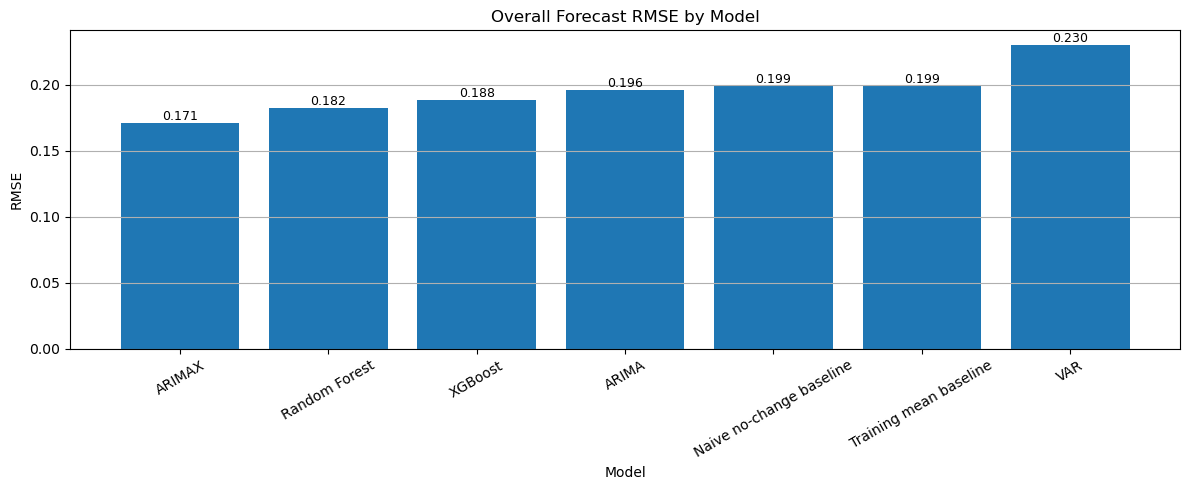

In [53]:
# Final model comparison table

model_results = pd.concat(
    [
        baseline_results,
        arima_results,
        arimax_results,
        var_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)

model_results["mse"] = model_results["rmse"] ** 2
model_results["high_stress_mse"] = model_results["high_stress_rmse"] ** 2

model_results = model_results[
    [
        "model",
        "rmse",
        "mse",
        "mae",
        "directional_accuracy",
        "high_stress_rmse",
        "high_stress_mse",
        "high_stress_mae"
    ]
].copy()

model_results["rmse_rank"] = model_results["rmse"].rank(method="min")
model_results["mae_rank"] = model_results["mae"].rank(method="min")
model_results["direction_rank"] = model_results["directional_accuracy"].rank(method="min", ascending=False)
model_results["high_stress_rank"] = model_results["high_stress_rmse"].rank(method="min")

model_results_ranked = (
    model_results
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(model_results_ranked.round(4))

# Annotated overall forecast error plot

plot_df = model_results.sort_values("rmse").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(plot_df["model"], plot_df["rmse"])

ax.set_title("Overall Forecast RMSE by Model")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, axis="y")

for bar, value in zip(bars, plot_df["rmse"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Final Model Comparison Table Interpretation

The final model comparison table ranks all models using the same chronological test period. The ranking shows that ARIMAX is the strongest overall model by RMSE, with a test RMSE of approximately 0.171 and a MAE of approximately 0.123. This is the best overall squared-error performance and indicates that the controlled ARIMAX structure uses the market-based predictors more effectively than the other models.

Random Forest ranks second by RMSE, with an RMSE of approximately 0.182 and the lowest MAE at approximately 0.121. This means Random Forest performs well on average absolute error, but its larger RMSE compared with ARIMAX suggests that it misses some larger stress-change movements more severely.

XGBoost ranks third by RMSE, with an RMSE of approximately 0.188 and a MAE of approximately 0.126. It improves over ARIMA, both baseline models, and VAR, but it does not outperform ARIMAX or Random Forest overall.

ARIMA ranks fourth by RMSE, with an RMSE of approximately 0.196. This means the univariate stress-change history contains some useful forecasting information, but it is weaker than models that include market-based predictors.

The baseline models perform similarly, with RMSE values near 0.199. This confirms that forecasting weekly stress changes is difficult, because simple near-zero forecasts are hard to beat by a large margin.

VAR performs worst by RMSE, with an RMSE of approximately 0.230. This suggests that while VAR is useful for studying multivariate lead-lag relationships, it is not the best forecasting model for this target.

The high-stress metrics reinforce the same conclusion. ARIMAX has the best high-stress RMSE at approximately 0.186 and the best high-stress MAE at approximately 0.135. This is important because the project is focused not only on average forecast performance, but also on performance during weeks when financial stress rises sharply.

Overall, the final comparison identifies ARIMAX as the best primary forecasting model, Random Forest as the best directional-support model, XGBoost as a useful nonlinear credit-channel model, and VAR as a lead-lag diagnostic model rather than the strongest forecaster.

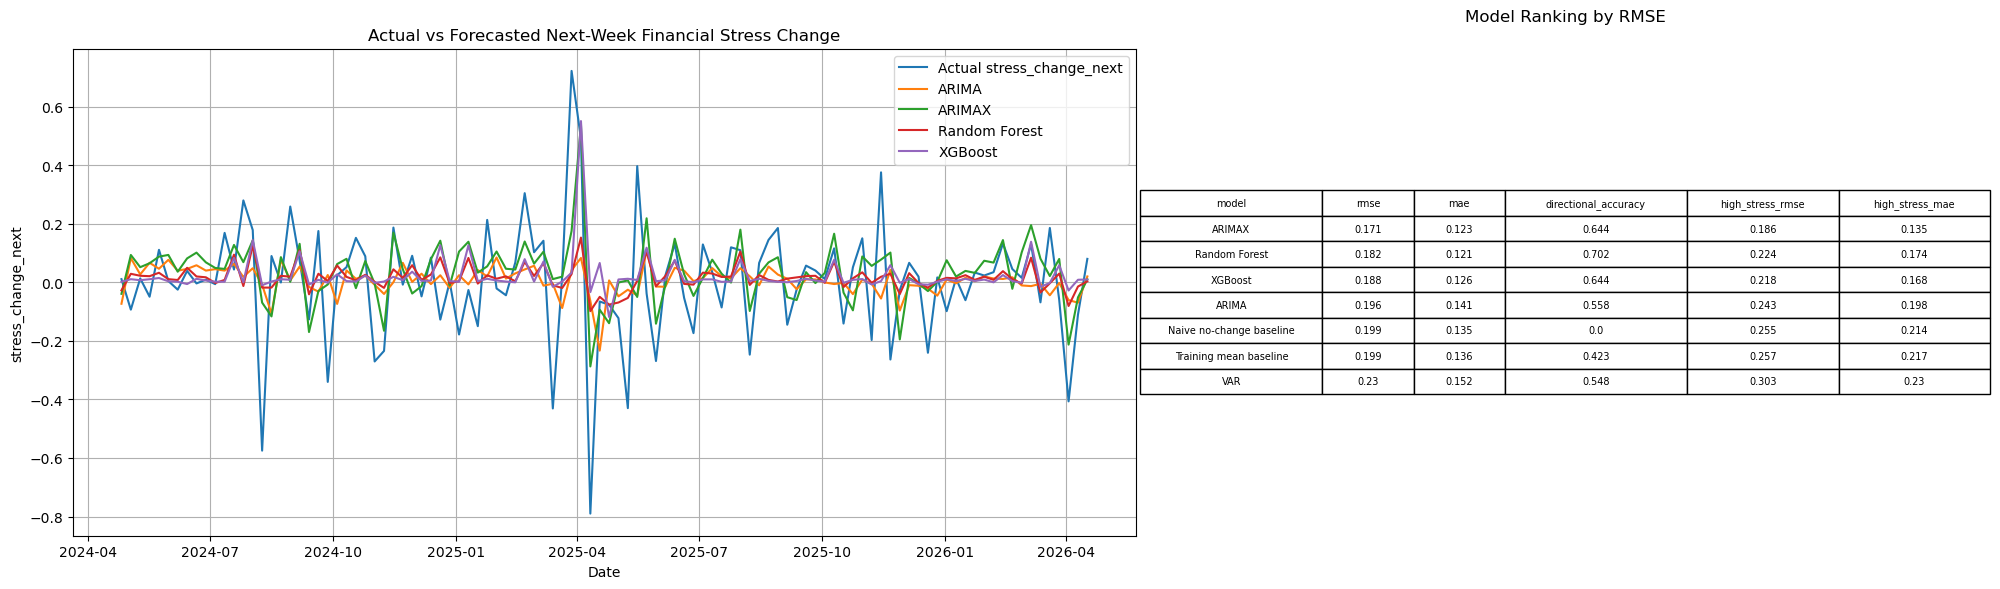

In [58]:
# Actual vs forecasted values with wider model ranking table

forecast_rank_table = (
    model_results[
        ["model", "rmse", "mae", "directional_accuracy", "high_stress_rmse", "high_stress_mae"]
    ]
    .sort_values("rmse")
    .reset_index(drop=True)
    .round(3)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 6),
    gridspec_kw={"width_ratios": [2.8, 2.0]}
)

axes[0].plot(test_df["date"], y_test.values, label="Actual stress_change_next")
axes[0].plot(test_df["date"], arima_forecasts, label="ARIMA")
axes[0].plot(test_df["date"], arimax_forecasts, label="ARIMAX")
axes[0].plot(test_df["date"], rf_forecasts, label="Random Forest")
axes[0].plot(test_df["date"], xgb_forecasts, label="XGBoost")

axes[0].set_title("Actual vs Forecasted Next-Week Financial Stress Change")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("stress_change_next")
axes[0].legend()
axes[0].grid(True)

axes[1].axis("off")

rank_table = axes[1].table(
    cellText=forecast_rank_table.values,
    colLabels=forecast_rank_table.columns,
    loc="center",
    cellLoc="center",
    colWidths=[0.24, 0.12, 0.12, 0.24, 0.20, 0.20]
)

rank_table.auto_set_font_size(False)
rank_table.set_fontsize(7)
rank_table.scale(1.0, 1.45)

axes[1].set_title("Model Ranking by RMSE", pad=20)

plt.tight_layout()
plt.show()

## Actual vs Forecasted Values Interpretation

The actual-versus-forecasted plot compares the main forecasting models against the observed next-week change in financial stress. The plot shows that all models struggle with the largest sudden stress shocks, especially the sharp positive and negative movements around stress-event periods. This is expected because abrupt financial-stress jumps are difficult to forecast from weekly lagged indicators.

ARIMA produces smoother forecasts near zero because it only uses the past behavior of `stress_change_next`. This makes it stable, but less responsive to market-channel information.

ARIMAX responds more strongly to changing market conditions and tracks several movements in the test period more closely than ARIMA. This visual pattern is consistent with the model ranking table, where ARIMAX has the lowest RMSE and the strongest high-stress-acceleration performance.

Random Forest and XGBoost also produce relatively conservative forecasts. Random Forest has the best directional accuracy, but its forecasts still miss some larger stress movements. XGBoost captures some stress-event movement but does not beat ARIMAX on overall or high-stress forecast error.

The ranking table beside the plot is important because visual inspection alone can be misleading. Numerically, ARIMAX ranks first by RMSE, Random Forest ranks second, XGBoost ranks third, ARIMA ranks fourth, the baseline models rank fifth and sixth, and VAR ranks last.

,feature,rf_importance,xgb_importance,average_importance
0,stress,0.09095,0.05701,0.07398
1,stress_lag1,0.07417,0.05915,0.06666
2,vix_change,0.09749,0.03523,0.06636
3,credit_spread_lag1,0.05781,0.07274,0.06528
4,vix_lag1,0.06333,0.06040,0.06187
5,vix_lag4,0.06553,0.05818,0.06186
6,sp500_return,0.07228,0.05105,0.06167
7,stress_lag4,0.04974,0.06821,0.05898
8,credit_spread_change,0.03770,0.07776,0.05773
9,credit_spread_lag4,0.01081,0.09794,0.05437


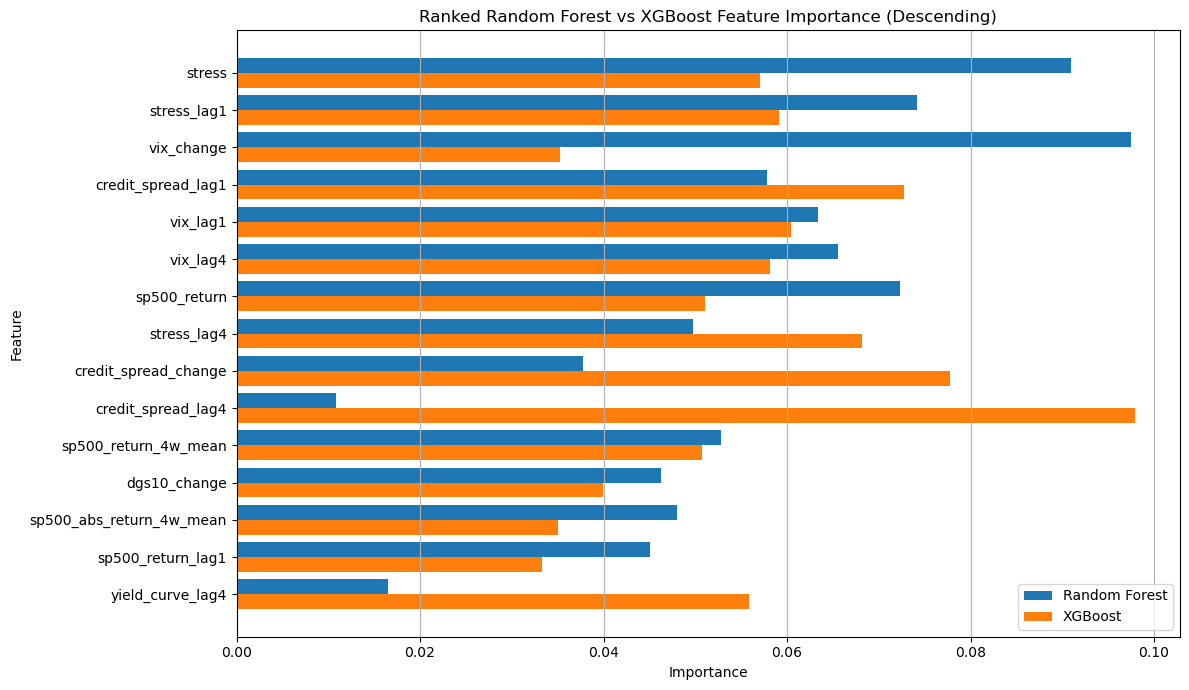

In [57]:
# Random Forest vs XGBoost feature importance comparison

rf_imp_compare = rf_feature_importance.rename(columns={"importance": "rf_importance"})
xgb_imp_compare = xgb_feature_importance.rename(columns={"importance": "xgb_importance"})

feature_importance_comparison = (
    pd.merge(rf_imp_compare, xgb_imp_compare, on="feature", how="outer")
    .fillna(0)
)

feature_importance_comparison["average_importance"] = (
    feature_importance_comparison["rf_importance"] +
    feature_importance_comparison["xgb_importance"]
) / 2

feature_importance_comparison = (
    feature_importance_comparison
    .sort_values("average_importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_comparison.round(5))

top_features = feature_importance_comparison.head(15).copy()

fig, ax = plt.subplots(figsize=(12, 7))

y_pos = np.arange(len(top_features))

ax.barh(y_pos - 0.2, top_features["rf_importance"], height=0.4, label="Random Forest")
ax.barh(y_pos + 0.2, top_features["xgb_importance"], height=0.4, label="XGBoost")

ax.set_yticks(y_pos)
ax.set_yticklabels(top_features["feature"])
ax.invert_yaxis()

ax.set_title("Ranked Random Forest vs XGBoost Feature Importance (Descending)")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.legend()
ax.grid(True, axis="x")

plt.tight_layout()
plt.show()

## Random Forest vs XGBoost Feature Importance Interpretation

The combined feature-importance table ranks predictors by average importance across Random Forest and XGBoost. The table is sorted in descending order, so the features at the top have the highest combined nonlinear-model importance, while the features at the bottom contribute the least across the two models.

The highest average-importance feature is current `stress`, with average importance of approximately 0.074. This indicates that the current level of financial stress remains highly informative for forecasting next-week stress changes, likely because it captures persistence and mean-reversion behavior.

The next strongest features include `stress_lag1` with average importance around 0.067, `vix_change` around 0.066, `credit_spread_lag1` around 0.065, `vix_lag1` around 0.062, and `vix_lag4` around 0.062. These results show that stress persistence, volatility changes, lagged volatility, and credit conditions are the most important nonlinear signal groups.

The models do not rank every feature the same way. Random Forest gives more weight to current stress, `vix_change`, and equity-market variables. XGBoost gives more weight to credit-spread variables, especially `credit_spread_lag4`, `credit_spread_change`, and `credit_spread_lag1`.

This difference is expected because the two algorithms calculate feature importance differently. Random Forest feature importance in scikit-learn is impurity-based, while the XGBoost model in this notebook was configured with gain-based feature importance. Therefore, the two rankings should be interpreted as model-specific channel rankings rather than identical coefficient estimates. Scikit-learn also cautions that impurity-based tree importances can be biased, so these rankings should be treated as descriptive model diagnostics rather than causal estimates. :contentReference[oaicite:0]{index=0}

The main conclusion is that volatility and credit variables are the strongest market-channel groups, while current and lagged stress capture persistence and mean-reversion. Equity returns provide secondary information. Treasury and yield-curve variables contribute less consistently, although selected yield-curve and Treasury features still appear in the middle of the rankings.

In [48]:
# Forecast-error diagnostic summary

def extract_ljung_box_pvalues(lb_df):
    return {
        "lb_pvalue_lag10": lb_df["lb_pvalue"].iloc[0],
        "lb_pvalue_lag20": lb_df["lb_pvalue"].iloc[1]
    }

diagnostic_rows = []

for model_name, lb_df in [
    ("ARIMA", ljung_box_arima),
    ("ARIMAX", ljung_box_arimax),
    ("VAR", ljung_box_var),
    ("Random Forest", ljung_box_rf),
    ("XGBoost", ljung_box_xgb)
]:
    row = {"model": model_name}
    row.update(extract_ljung_box_pvalues(lb_df))
    diagnostic_rows.append(row)

diagnostic_summary = pd.DataFrame(diagnostic_rows)

diagnostic_summary["lag10_autocorrelation_flag"] = diagnostic_summary["lb_pvalue_lag10"] < 0.05
diagnostic_summary["lag20_autocorrelation_flag"] = diagnostic_summary["lb_pvalue_lag20"] < 0.05

display(diagnostic_summary)

,model,lb_pvalue_lag10,lb_pvalue_lag20,lag10_autocorrelation_flag,lag20_autocorrelation_flag
0,ARIMA,0.860767,0.987071,False,False
1,ARIMAX,0.874116,0.956522,False,False
2,VAR,0.686465,0.898389,False,False
3,Random Forest,0.011532,0.196907,True,False
4,XGBoost,0.005637,0.121045,True,False


## Final Model Comparison Interpretation

The final comparison shows that rolling ARIMAX is the strongest overall forecasting model. ARIMAX has the best RMSE and the strongest high-stress-acceleration performance, which means it handles both average forecast accuracy and stress-event weeks better than the other models.

Random Forest is the strongest directional model. It produces the highest directional accuracy, meaning it is most useful for predicting whether financial stress will rise or fall. However, Random Forest does not beat ARIMAX on RMSE or high-stress-acceleration error.

XGBoost improves over the baselines, ARIMA, and VAR, but it does not outperform ARIMAX. Its main value is feature-importance interpretation, where it identifies credit-spread variables as the strongest nonlinear signal group.

VAR provides useful evidence of multivariate lead-lag dynamics, but it is not the strongest forecasting model. Its forecast errors are larger than those of ARIMAX, Random Forest, and XGBoost. This suggests that modeling the full multivariate system jointly does not necessarily improve next-week stress-change forecasting.

Overall, the results show that market-based predictors matter, but a controlled linear ARIMAX structure performs better than the unrestricted VAR system and the nonlinear tree models for this specific weekly financial-stress forecasting task.

# Research Question Answers

## Research Question 1

**Which financial channel provides the strongest incremental signal for next-week changes in U.S. financial stress: equity volatility, credit spreads, equity returns, or interest-rate/yield-curve variables?**

The strongest signals come from volatility and credit-market variables. The evidence differs slightly by model.

In ARIMAX, VIX changes and credit-spread changes are statistically important predictors. The coefficient on `vix_change` is positive and significant, and the coefficient on `credit_spread_change` is also positive and significant. This suggests that increases in equity-market volatility and widening credit spreads are associated with larger next-week financial stress changes.

In Random Forest, the most important feature is `vix_change`, with importance around 0.0975. Current financial stress is second, with importance around 0.0909, followed by `stress_lag1`, `sp500_return`, and VIX lag variables. This suggests that Random Forest relies most heavily on volatility changes, current stress conditions, and equity-market behavior.

In XGBoost, the strongest features are credit-spread variables. `credit_spread_lag4` has importance around 0.097, followed by `credit_spread_change` around 0.078 and `credit_spread_lag1` around 0.073. This suggests that XGBoost places the strongest weight on the credit channel.

Overall, the answer is not one single variable across all models. The strongest channel group is volatility and credit. VIX is the strongest immediate volatility signal, while credit spreads are the strongest slower-moving stress signal. Equity returns are useful but secondary. Treasury and yield-curve variables contribute less consistently.

## Research Question 2

**Do volatility, credit, equity, and yield-curve indicators move together with financial stress, or does one channel consistently lead changes in STLFSI4 by one to four weeks?**

The evidence suggests that the channels are related, but they do not produce one clean, stable lead-lag hierarchy across every model.

The correlation analysis shows that the stress level is strongly related to VIX and credit spreads. However, correlations with `stress_change_next` are weaker, which means forecasting changes in financial stress is harder than explaining the level of stress.

The lead-lag analysis shows that the strongest short-horizon relationships are modest. VIX changes, S&P 500 returns, and credit-spread changes provide the clearest near-term signals, but the correlations are not large enough to claim a simple mechanical lead relationship.

The VAR model supports the existence of multivariate lead-lag dynamics. The selected VAR lag order is 4, meaning approximately one month of lagged weekly information is useful inside the multivariate system. In the `stress_change_next` equation, lagged stress changes and several lagged VIX changes are statistically meaningful. Selected credit-spread, S&P 500 return, and 2-year Treasury-yield terms also contribute.

However, VAR underperforms ARIMAX in out-of-sample forecasting. This means that while the indicators interact over time, the full multivariate VAR system is not the best forecasting tool in this project.

Overall, volatility and credit variables provide the clearest lead-lag information. The channels do move together during stress periods, but the evidence points more toward near-coincident and short-lag relationships than a single channel consistently leading all others by one to four weeks.

## Research Question 3

**Do nonlinear models reduce forecast error during high-stress-acceleration weeks compared with ARIMA, ARIMAX, and VAR?**

The nonlinear models improve over ARIMA and VAR, but they do not outperform ARIMAX during high-stress-acceleration weeks.

Random Forest produces strong directional accuracy and a low MAE, but its high-stress RMSE and high-stress MAE are weaker than ARIMAX. XGBoost performs better than Random Forest during high-stress weeks, but it still does not beat ARIMAX.

ARIMAX has the strongest high-stress-acceleration performance, with high-stress RMSE around 0.186 and high-stress MAE around 0.135. Random Forest has high-stress RMSE around 0.224 and high-stress MAE around 0.174. XGBoost has high-stress RMSE around 0.218 and high-stress MAE around 0.168. VAR performs worst among the main models during high-stress weeks.

Therefore, the answer is mixed. Nonlinear models add value compared with ARIMA and VAR, but they do not beat ARIMAX on the project’s most important stress-acceleration metrics. Random Forest is best for directional accuracy, while ARIMAX is best for high-stress forecast error.

# Final Model Conclusion

The strongest model in this analysis is rolling ARIMAX. It provides the best combination of overall RMSE, overall MAE, and high-stress-acceleration performance. This suggests that a controlled linear time-series model with carefully selected market predictors is more effective than the unrestricted VAR system and the nonlinear tree models for this dataset.

Random Forest remains useful because it produces the strongest directional accuracy. If the goal is to classify whether financial stress will rise or fall, Random Forest is the best supporting model. However, if the goal is to minimize forecast error during stress-acceleration weeks, ARIMAX is stronger.

XGBoost is useful for identifying credit-market importance. Its feature rankings show that credit-spread variables are central to nonlinear stress forecasting. However, its predictive performance does not justify choosing it over ARIMAX as the main model.

VAR is useful as a lead-lag diagnostic model but not as the final forecasting model. It supports the existence of multivariate financial-channel dynamics, but its forecast performance is weaker.

The final business interpretation is that volatility and credit-market conditions are the most useful financial stress indicators. VIX changes provide immediate stress information, while credit spreads provide slower-moving credit-risk information. Equity returns add useful supporting information, while Treasury and yield-curve variables are less consistent short-horizon predictors.

For a practical risk-monitoring workflow, ARIMAX should be used as the primary forecast model, Random Forest should be used as a directional support model, and XGBoost feature importance should be used to monitor which financial channels are becoming more important over time.

# Limitations and Future Work

This analysis has several limitations. First, the sample period covers roughly ten years of weekly data, which provides enough observations for a structured comparison but may still be limited for capturing rare financial-stress regimes. Second, the test period contains specific market conditions from 2024 to 2026, so the model rankings may change under different macroeconomic regimes.

Third, the Random Forest and XGBoost models use engineered lag features, but they do not explicitly model time-series dependence in the same way as ARIMA, ARIMAX, or VAR. Their forecast-error diagnostics showed some short-run autocorrelation, suggesting that these models may leave some temporal structure unexplained.

Fourth, feature importance from tree-based models should be interpreted as model-specific importance, not as causal evidence. The results indicate which variables helped the fitted models reduce prediction error, not which variables caused financial stress changes.

Future work could expand the feature set by adding additional credit-market indicators, funding-market spreads, financial-sector equity returns, or macroeconomic release variables. Future versions could also test rolling-window retraining, Diebold-Mariano forecast comparison tests, and threshold-based classification models for high-stress-acceleration weeks.

# References

Ballings, M., Van den Poel, D., Hespeels, N., & Gryp, R. (2015). Evaluating multiple classifiers for stock price direction prediction. *Expert Systems with Applications, 42*(20), 7046–7056. https://doi.org/10.1016/j.eswa.2015.05.013

Bergmeir, C., Hyndman, R. J., & Koo, B. (2018). A note on the validity of cross-validation for evaluating autoregressive time series prediction. *Computational Statistics & Data Analysis, 120*, 70–83. https://doi.org/10.1016/j.csda.2017.11.003

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time series analysis: Forecasting and control*. Wiley. https://doi.org/10.1002/9781118675021

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*. https://doi.org/10.1145/2939672.2939785

Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics, 13*(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599

Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2018). Statistical and machine learning forecasting methods: Concerns and ways forward. *PLOS ONE, 13*(3). https://doi.org/10.1371/journal.pone.0194889

Tsay, R. S. (2010). *Analysis of financial time series*. Wiley. https://doi.org/10.1002/9780470644560